# Darcy Flow in 2 dimensions

Authored by Aleksei G. Sorokin

## Setup

In [1]:
import glob 
import os
import sys; 
sys.path.append("../")

In [2]:
import fastgps
import chonknoris
import gpytorch
import torch
import lightning
import qmcpy as qp
import numpy as np

In [3]:
torch.set_default_dtype(torch.float64)
assert torch.cuda.is_available()
DEVICE = "cuda:0"

In [4]:
ROOT = "."
assert os.path.isfile(ROOT+"/darcy_2d.ipynb")

In [5]:
from matplotlib import pyplot,colors,cm,cycler
import pandas as pd
pyplot.style.use('seaborn-v0_8-whitegrid')
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv(ROOT+"/../../chonknoris/xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
pyplot.rcParams['axes.prop_cycle'] = cycler(color=COLORS)

## Parameters

In [6]:
FACTOR = 1
num_realizations = 2**10
N1,N2 = 20,20 # grid of size N1 x N2
L1,L2 = 1.,1. # domain of size [0,L1] x [0,L2]

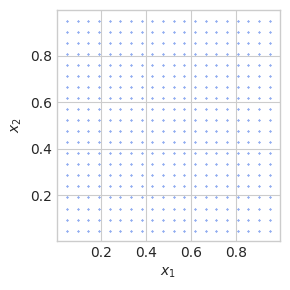

In [7]:
N = N1*N2
x1 = torch.linspace(0,L1,N1+2,device=DEVICE)[1:-1]
x2 = torch.linspace(0,L2,N2+2,device=DEVICE)[1:-1]
dx1 = (x1[1]-x1[0]).item()
dx2 = (x2[1]-x2[0]).item()
x1mesh,x2mesh = torch.meshgrid(x1,x2,indexing="ij")
xticks = torch.vstack([x1mesh.flatten(),x2mesh.flatten()]).T 
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(3,3))
ax.scatter(xticks[:,0].cpu(),xticks[:,1].cpu(),color=COLORS[0],s=.1)
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$");
#ax.set_xlim([0,L1]); ax.set_ylim([0,L2]);
fig.tight_layout()

## Reference data

### $f$

f.shape = (20, 20)


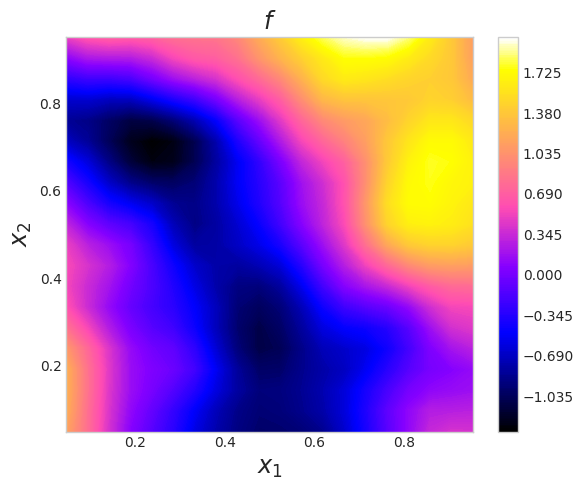

In [8]:
f_kernel = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=5/2,ard_num_dims=2))
f_kernel.outputscale = 1e0
f_kernel.base_kernel.lengthscale = torch.tensor([3e-1,3e-1])
# f_kernel.base_kernel.lengthscale = torch.tensor([1e-1,1e-1])
f_gp = chonknoris.GP(
    x = torch.zeros((0,2)),
    y = torch.zeros(0),
    mean_module = gpytorch.means.ZeroMean(),
    covar_module = f_kernel)
f_gp.to(DEVICE)
f_x_mvn = f_gp.forward(xticks)
#f = f_x_mvn.sample().reshape((N1,N2))
f = f_x_mvn.sample(torch.Size([1]),base_samples=torch.randn(1,N,generator=torch.Generator().manual_seed(17)).to(DEVICE)).reshape((N1,N2))
print("f.shape = %s"%str(tuple(f.shape)))
fig,ax = chonknoris.plot_contourfs(
    data = [[(x1mesh.cpu(),x2mesh.cpu(),f.cpu())]],
    cmap = cm.gnuplot2,
    xlabels = r"$x_1$",
    ylabels = r"$x_2$",
    titles = r"$f$",contourf_level=250)
fig.savefig("out/f.png",dpi=256)

### $u$

u.shape = (1024, 3, 20, 20)


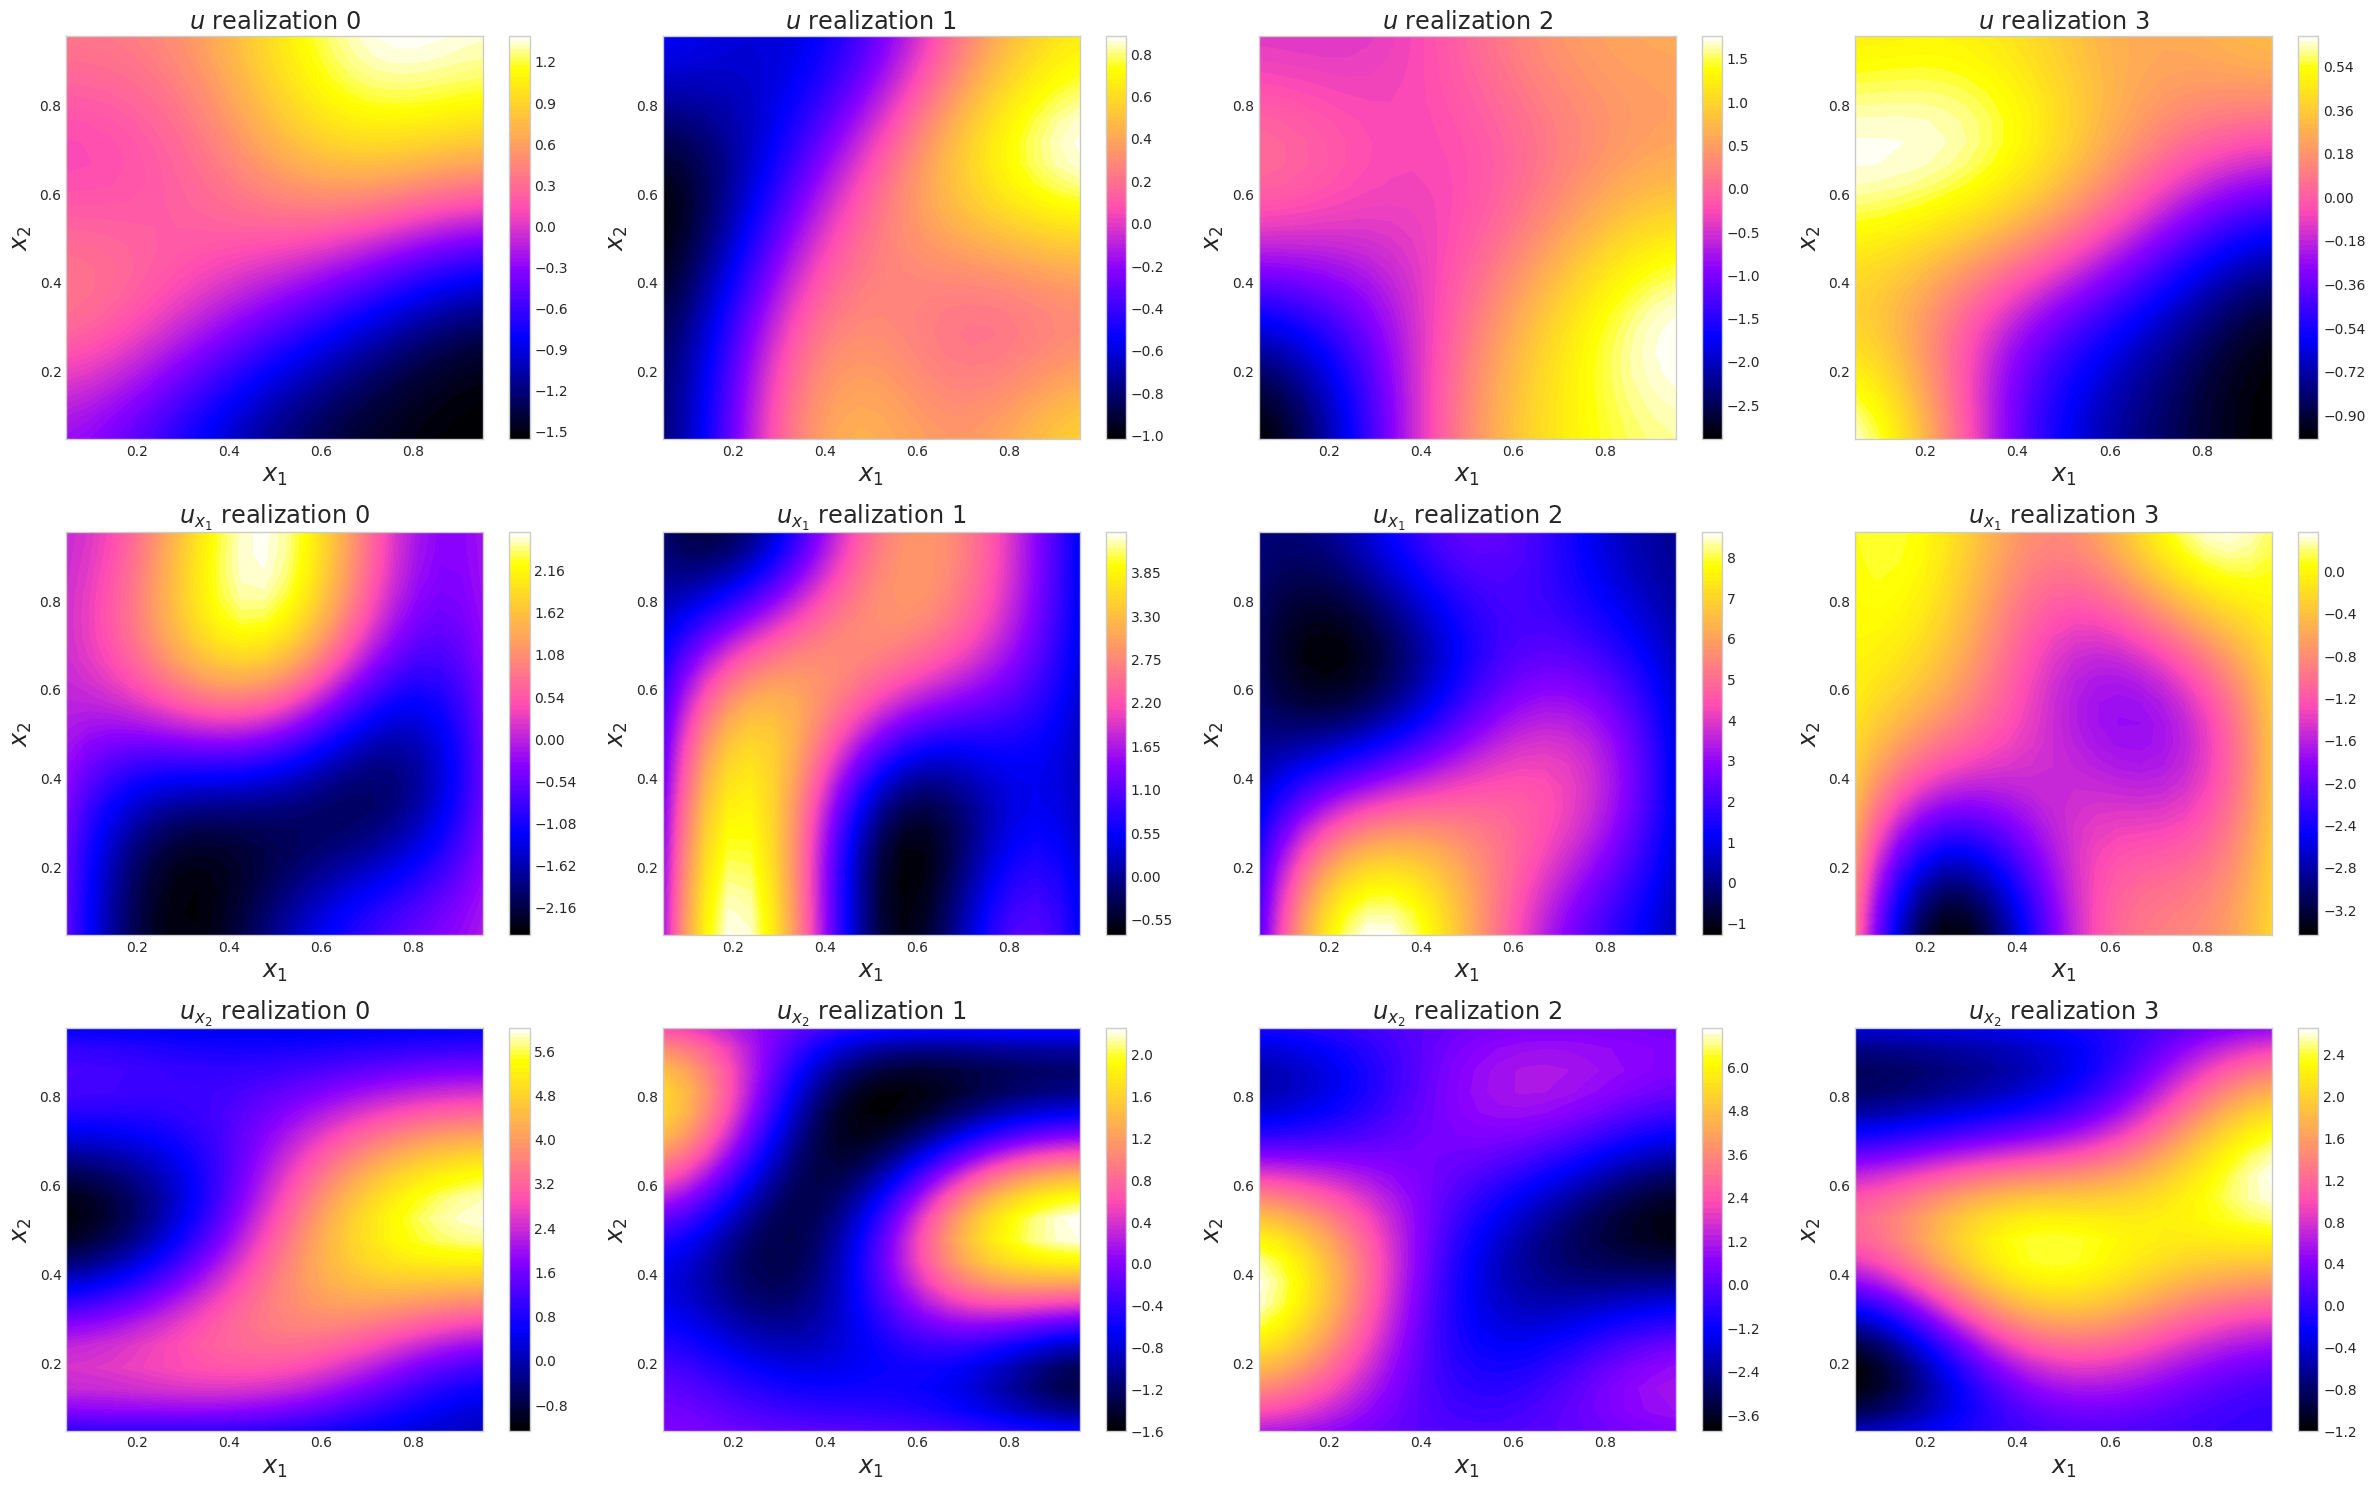

In [9]:
if False:
    #u_kernel = gpytorch.kernels.ScaleKernel(gpytorch.kernels.PolynomialKernelGrad(power=2))
    u_kernel = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernelGrad(ard_num_dims=2))
    # u_kernel.base_kernel.lengthscale = torch.tensor([5e-1,5e-1],device=DEVICE)
    u_kernel.base_kernel.lengthscale = torch.tensor([2.5e-1,2.5e-1],device=DEVICE)
    u_kernel.outputscale = 1
    u_gp = chonknoris.MultiTaskVecGP(
        x = torch.zeros((0,2)),
        y = torch.zeros(0,3),
        mean_module = gpytorch.means.ConstantMeanGrad(),
        covar_module = u_kernel)
    u_gp.to(DEVICE)
    u_x_mvn = u_gp.forward(xticks)
    # u = torch.permute(u_x_mvn.sample(torch.Size([num_realizations]),base_samples=torch.randn(num_realizations,N,3,generator=torch.Generator().manual_seed(11)).to(DEVICE)),[0,2,1]).reshape((num_realizations,3,N1,N2))
    u = torch.permute(u_x_mvn.sample(torch.Size([num_realizations])),[0,2,1]).reshape((num_realizations,3,N1,N2))
else:
    from util import build_kl_modes_2d
    x1mesh_g = x1mesh.clone().requires_grad_().cpu()
    x2mesh_g = x2mesh.clone().requires_grad_().cpu()
    lam,psi = build_kl_modes_2d(x1mesh_g, x2mesh_g, tau=1e-1, d=2e0, Ntheta=12, lmax=30)
    theta  = torch.randn((num_realizations,lam.shape[0]),generator=torch.Generator().manual_seed(11))   # each ~ N(0,1)
    coeffs = theta * lam.sqrt()  # shape (Nθ,)
    _u0 = (coeffs[...,None,None]*psi).sum(-3)
    dpsi1 = torch.cat([torch.autograd.grad(psi[i],x1mesh_g,grad_outputs=torch.ones_like(psi[i]),create_graph=True)[0][None,:,:] for i in range(psi.size(0))],dim=0)
    dpsi2 = torch.cat([torch.autograd.grad(psi[i],x2mesh_g,grad_outputs=torch.ones_like(psi[i]),create_graph=True)[0][None,:,:] for i in range(psi.size(0))],dim=0)
    _u1 = (coeffs[...,None,None]*dpsi1).sum(-3)
    _u2 = (coeffs[...,None,None]*dpsi2).sum(-3)
    if True: # set to True to ensure gradients computed correctly
        _u1_slow5 = torch.cat([torch.autograd.grad(_u0[i],x1mesh_g,grad_outputs=torch.ones(_u0[i].shape),retain_graph=True)[0][None,:,:] for i in range(5)],dim=0)
        assert torch.allclose(_u1[:5],_u1_slow5)
        _u2_slow5 = torch.cat([torch.autograd.grad(_u0[i],x2mesh_g,grad_outputs=torch.ones(_u0[i].shape),retain_graph=True)[0][None,:,:] for i in range(5)],dim=0)
        assert torch.allclose(_u2[:5],_u2_slow5)
    u = 5*torch.cat([_u0[:,None,:,:].detach().to(DEVICE),_u1[:,None,:,:].detach().to(DEVICE),_u2[:,None,:,:].detach().to(DEVICE)],dim=1)
print("u.shape = %s"%str(tuple(u.shape)))
fig,ax = chonknoris.plot_contourfs(
    data = [[(x1mesh.cpu(),x2mesh.cpu(),u[i,j].cpu()) for i in range(4)] for j in range(3)],
    xlabels = r"$x_1$",
    ylabels = r"$x_2$",
    titles = [
        [r"$u$ realization %d"%i for i in range(4)],
        [r"$u_{x_1}$ realization %d"%i for i in range(4)],
        [r"$u_{x_2}$ realization %d"%i for i in range(4)]],
    cmap = cm.gnuplot2)
fig.savefig("out/u.png",dpi=256)

### Initial guess $v_0$

In [10]:
if False: 
    assert False, "UPDATE to require boundary=0"
    v0_kernel = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=5/2,ard_num_dims=2))
    v0_kernel.outputscale = 1.
    v0_kernel.base_kernel.lengthscale = torch.tensor([1e0,1e0])
    v0_gp = chonknoris.GP(
        x = torch.zeros((0,1)),
        y = torch.zeros(0),
        mean_module = gpytorch.means.ZeroMean(),
        covar_module = v0_kernel)
    v0_gp.to(DEVICE)
    v0_x_mvn = v0_gp.forward(xticks)
    v0 = v0_x_mvn.sample(torch.Size([num_realizations])).reshape((num_realizations,N1,N2))
    fig,ax = chonknoris.plot_contourfs(
        data = [[(x1mesh.cpu(),x2mesh.cpu(),v0[i].cpu()) for i in range(4)]],
        cmap = cm.plasma,
        xlabels = r"$x_1$",
        ylabels = r"$x_2$",
        titles = [[r"$v_0$ realization %d"%i for i in range(4)]])
else:
    v0 = torch.zeros((num_realizations,N1,N2),device=DEVICE)
print("v0.shape = %s"%str(tuple(v0.shape)))

v0.shape = (1024, 20, 20)


### Gauss-Newton solver

In [11]:
def pde_solve(
        f, 
        u, 
        v0, 
        num_newton_iter = 6, 
        relaxation = 0, 
        lr = 1, 
        line_search = False, 
        line_search_c1 = 1e-4, 
        line_search_beta = .3,
        line_search_min_lr = 1e-16,
        vref = None, 
        predict_Linvs = None, 
        store_Linvs = False, 
        verbose = True,
        verbose_indent = 4,
        relaxation_to_store = None):
    t0 = torch.cuda.Event(enable_timing=True)
    tend = torch.cuda.Event(enable_timing=True)
    t0.record()
    assert f.ndim==2 and u.ndim==4 and v0.ndim==3
    R = len(u) # number of realizations
    assert f.shape==(N1,N2) and u.shape==(R,3,N1,N2) and v0.shape==(R,N1,N2)
    assert vref is None or vref=="last" or isinstance(vref,torch.Tensor)
    N1range = torch.arange(N1,device=DEVICE)
    N2range = torch.arange(N2,device=DEVICE)
    Nrange = torch.arange(N,device=DEVICE)
    # A_laplace.shape == (N,N)
    A1 = torch.zeros((N1,N2,N1,N2),device=DEVICE)
    for k in range(N2):
        A1[N1range[1:],k,N1range[:-1],k] = 1
        A1[N1range,k,N1range,k] = -2
        A1[N1range[:-1],k,N1range[1:],k] = 1
    A2 = torch.zeros((N1,N2,N1,N2),device=DEVICE)
    for k in range(N1):
        A2[k,N2range[1:],k,N2range[:-1]] = 1
        A2[k,N2range,k,N2range] = -2
        A2[k,N2range[:-1],k,N2range[1:]] = 1
    A_laplace = (A1/dx1**2+A2/dx2**2).reshape((N,N))
    # C1.shape == C2.shape == (N,N)
    C1 = torch.zeros((N1,N2,N1,N2),device=DEVICE) 
    C2 = torch.zeros((N1,N2,N1,N2),device=DEVICE) 
    for k in range(N2):
        C1[N1range[:-1],k,N1range[1:],k] = 1
        C1[N1range[1:],k,N1range[:-1],k] = -1
    for k in range(N1):
        C2[k,N2range[:-1],k,N2range[1:]] = 1
        C2[k,N2range[1:],k,N2range[:-1]] = -1
    C1 = C1.reshape((N,N))/(2*dx1)
    C2 = C2.reshape((N,N))/(2*dx2)
    vs = torch.empty((R,num_newton_iter+1,N))
    resid = torch.empty((R,num_newton_iter+1,N))
    rmse_resid = torch.empty(R,num_newton_iter+1)
    times = torch.empty(num_newton_iter+1)
    if store_Linvs:
        Linvs = torch.zeros((R,num_newton_iter,N,N))
    if relaxation_to_store is not None:
        assert relaxation_to_store>relaxation and predict_Linvs is None
    if line_search:
        lr_lss = torch.empty((R,num_newton_iter))
    if isinstance(vref,torch.Tensor):
        assert vref.shape==(R,N1,N2)
        vref = vref.reshape((-1,N))
        vrefnorm = torch.linalg.norm(vref,dim=1)
        l2rerrors = torch.empty((R,num_newton_iter+1))
    if verbose:
        _vstr = " "*verbose_indent+"%-15s| %-10s| %-65s|"%("iter of %-6d"%num_newton_iter,"time","RMSE residual")
        if isinstance(vref,torch.Tensor):
            _vstr += " %-52s|"%"L2 relative error"
        print(_vstr)
        _vstr = " "*verbose_indent+"%-15s| %-10s| %-13s%-13s%-13s%-13s%-13s|"%(" "*15," "*10,"5%","median","mean","95%","finite %")
        if isinstance(vref,torch.Tensor):
            _vstr += " %-13s%-13s%-13s%-13s|"%("5%","median","mean","95%")
        print(_vstr)
        _vstr = " "*verbose_indent+"-"*(len(_vstr)-verbose_indent)
        if isinstance(vref,torch.Tensor):
            _vstr += "-"*54
        print(_vstr)
    # v.shape==(R,N)
    u = u.reshape((R,3,N))
    v = v0.reshape((R,N))
    def F(u, v, check=False):
        u0,u_x1,u_x2 = u[:,0],u[:,1],u[:,2]
        C1v = torch.einsum("ik,rk->ri",C1,v)
        C2v = torch.einsum("ik,rk->ri",C2,v)
        Av = torch.einsum("ik,rk->ri",A_laplace,v)
        if check:
            _v = v.reshape((-1,N1,N2))
            _C1v = (_v[:,2:,1:9]-_v[:,:-2,1:9])/(2*dx1) 
            assert torch.allclose(_C1v,C1v.reshape((-1,N1,N2))[:,1:-1,1:-1])
            _C2v = (_v[:,1:9,2:]-_v[:,1:9,:-2])/(2*dx2) 
            assert torch.allclose(_C2v,C2v.reshape((-1,N1,N2))[:,1:-1,1:-1])
            _Av = (_v[:,2:,1:9]-2*_v[:,1:-1,1:9]+_v[:,:-2,1:9])/dx1**2+(_v[:,1:9,2:]-2*_v[:,1:9,1:-1]+_v[:,1:9,:-2])/dx2**2
            assert torch.allclose(_Av,Av.reshape((-1,N1,N2))[:,1:-1,1:-1])
        y = -torch.exp(u0)*(u_x1*C1v+u_x2*C2v+Av)+FACTOR*v**3-f.flatten()
        return y
    def partial_F(u, v):
        u0,u_x1,u_x2 = u[:,0],u[:,1],u[:,2]
        y = -torch.exp(u0)[:,:,None]*(u_x1[:,:,None]*C1+u_x2[:,:,None]*C2+A_laplace)+3*FACTOR*(v**2)[:,:,None]*torch.eye(N,device=DEVICE)
        return y
    residual = F(u,v)
    for i in range(num_newton_iter+1):
        vs[:,i,:] = v.cpu()
        resid[:,i,:] = residual.cpu()
        rmse_resid[:,i] = torch.sqrt(torch.mean(residual**2,1)).cpu()
        if isinstance(vref,torch.Tensor):
            l2rerrors[:,i] = (torch.linalg.norm(v-vref,dim=1)/vrefnorm).cpu()
        tend.record()
        torch.cuda.synchronize()
        times[i] = t0.elapsed_time(tend)/1000/R
        t0 = torch.cuda.Event(enable_timing=True)
        tend = torch.cuda.Event(enable_timing=True)
        t0.record()
        if verbose and (i%verbose==0 or i==num_newton_iter):
            _vstr = " "*verbose_indent+"%-15d| %-10.2e| %-13.2e%-13.2e%-13.2e%-13.2e%-13.1f|"%(i,times[i]*R,
                    torch.nanquantile(rmse_resid[:,i],.05),torch.nanquantile(rmse_resid[:,i],.5),torch.nanmean(rmse_resid[:,i]),torch.nanquantile(rmse_resid[:,i],.95),100*torch.mean(torch.isfinite(rmse_resid[:,i]).to(torch.float)))
            if isinstance(vref,torch.Tensor):
                _vstr += " %-13.2e%-13.2e%-13.2e%-13.2e|"%(
                    torch.nanquantile(l2rerrors[:,i],.05),torch.nanquantile(l2rerrors[:,i],.5),torch.nanmean(l2rerrors[:,i]),torch.nanquantile(l2rerrors[:,i],.95))
            print(_vstr)
        if i==num_newton_iter: break
        # dFdv.shape == (R,N,N)
        dFdv = partial_F(u,v)
        if predict_Linvs is None: 
            # Theta.shape==(R,N,N)
            Theta = torch.einsum("rki,rkj->rij",dFdv,dFdv) # batch dFdv[r].T@dFdv[r]
            Theta[:,Nrange,Nrange] = Theta[:,Nrange,Nrange]+relaxation # add to diagonals
            # L.shape==Linv.shape==(R,N,N)
            L = torch.linalg.cholesky(Theta,upper=False)
            Linv = torch.linalg.solve_triangular(L,torch.eye(N,device=DEVICE),upper=False)
        else:
            Linv = predict_Linvs(v,u)
        if store_Linvs:
            if relaxation_to_store is not None:
                Theta[:,Nrange,Nrange] = Theta[:,Nrange,Nrange]+(relaxation_to_store-relaxation) # add to diagonals
                L_for_store = torch.linalg.cholesky(Theta,upper=False)
                Linvs_to_store = torch.linalg.solve_triangular(L_for_store,torch.eye(N,device=DEVICE),upper=False)
            else:
                Linvs_to_store = Linv
            Linvs[:,i,:,:] = Linvs_to_store.cpu()
        # b.shape==delta.shape==v_new.shape==residual.shape==(R,N)
        b = torch.einsum("rik,ri->rk",dFdv,residual)
        delta = torch.einsum("rik,ri->rk",Linv,torch.einsum("rik,rk->ri",Linv,b)) # batch Linv[r].T@(Linv[r]@b[r])
        v_new = v-lr*delta
        residual_new = F(u,v_new) # previously this was F(u,v) which I think is wrong
        if line_search:
            v_clone = v.clone()
            residual_clone = residual.clone()
            mask = torch.ones(R,dtype=bool,device=DEVICE)
            lr_ls = lr*torch.ones(R,device=DEVICE)
            _temp1 = torch.linalg.norm(residual,dim=1)**2
            _temp2 = 2*line_search_c1*(b*delta).sum(1)
            while True:
                _mask = mask.clone()
                mask[_mask] = (torch.linalg.norm(residual_new[_mask],dim=1)**2)>(_temp1[_mask]+lr_ls[_mask]*_temp2[_mask])
                if mask.sum()==0: break 
                if lr_ls[mask].min()<=line_search_min_lr:
                    v_new[mask] = v_clone[mask]
                    residual_new[mask] = residual_clone[mask]
                    break
                lr_ls[mask] = lr_ls[mask]*line_search_beta
                v_new[mask] = v[mask]-lr_ls[mask,None]*delta[mask]
                residual_new[mask] = F(u[mask],v_new[mask])
            lr_lss[:,i] = lr_ls.cpu()
        v = v_new 
        residual = residual_new
    if vref=="last":
        vref = vs[:,-1]
        l2rerrors = torch.linalg.norm(vs-vref[:,None,:],dim=2)/torch.linalg.norm(vref[:,None,:],dim=2)
    vs = vs.reshape((R,num_newton_iter+1,N1,N2))
    resid = resid.reshape((R,num_newton_iter+1,N1,N2))
    data = {"vs":vs,"resid":resid,"rmse_resid":rmse_resid,"times":torch.cumsum(times,0)}
    if store_Linvs:
        data["Linvs"] = Linvs
    if line_search:
        data["lr_lss"] = lr_lss
    if vref is not None:
        data["l2rerrors"] = l2rerrors
    return vs,data

### Generate data

In [12]:
import gc
gc.collect()
torch.cuda.empty_cache()
vs,data = pde_solve(f,u,v0,num_newton_iter=6,relaxation=0,lr=.75,store_Linvs=True,relaxation_to_store=1e-3,vref=None,verbose=1)
# vs,data = pde_solve(f,u,v0,num_newton_iter=6,relaxation=0,lr=1,store_Linvs=True,relaxation_to_store=1e-6,vref=None,verbose=1)
Linvs = data["Linvs"]
for key,val in data.items():
    print('data["%s"].shape = %s'%(key,str(tuple(val.shape))))

    iter of 6      | time      | RMSE residual                                                    |
                   |           | 5%           median       mean         95%          finite %     |
    -----------------------------------------------------------------------------------------------
    0              | 2.67e-01  | 8.80e-01     8.80e-01     8.80e-01     8.80e-01     100.0        |
    1              | 9.99e-01  | 2.20e-01     2.20e-01     2.20e-01     2.20e-01     100.0        |
    2              | 9.87e-01  | 5.50e-02     5.50e-02     5.50e-02     5.50e-02     100.0        |
    3              | 9.85e-01  | 1.37e-02     1.37e-02     1.37e-02     1.38e-02     100.0        |
    4              | 9.83e-01  | 3.44e-03     3.44e-03     3.44e-03     3.44e-03     100.0        |
    5              | 9.82e-01  | 8.59e-04     8.59e-04     8.59e-04     8.59e-04     100.0        |
    6              | 9.83e-01  | 2.15e-04     2.15e-04     2.15e-04     2.15e-04     100.0        |


### Train Test Split

In [13]:
(u_t,u_v,vs_t,vs_v,Linvs_t,Linvs_v),vidx = chonknoris.train_val_split(u,vs,Linvs,val_frac=1/8,shuffle=True,rng_shuffle_seed=7)
print("u_t.shape = %s"%str(tuple(u_t.shape)))
print("vs_t.shape = %s"%str(tuple(vs_t.shape)))
print("Linvs_t.shape = %s"%str(tuple(Linvs_t.shape)))
print()
print("u_v.shape = %s"%str(tuple(u_v.shape)))
print("vs_v.shape = %s"%str(tuple(vs_v.shape)))
print("Linvs_v.shape = %s"%str(tuple(Linvs_v.shape)))
# torch.save(
#     {
#         "u_t": u_t.cpu(),
#         "v_t": vs_t[:,-1,:,:].cpu(),
#         "u_v": u_v.cpu(),
#         "v_v": vs_v[:,-1,:,:].cpu(),
#     },
#     ROOT+"/out/darcy_pde_2d.data_Nx%dNy%d.train_val.pt"%(N1,N2))

u_t.shape = (896, 3, 20, 20)
vs_t.shape = (896, 7, 20, 20)
Linvs_t.shape = (896, 6, 400, 400)

u_v.shape = (128, 3, 20, 20)
vs_v.shape = (128, 7, 20, 20)
Linvs_v.shape = (128, 6, 400, 400)


### Plots

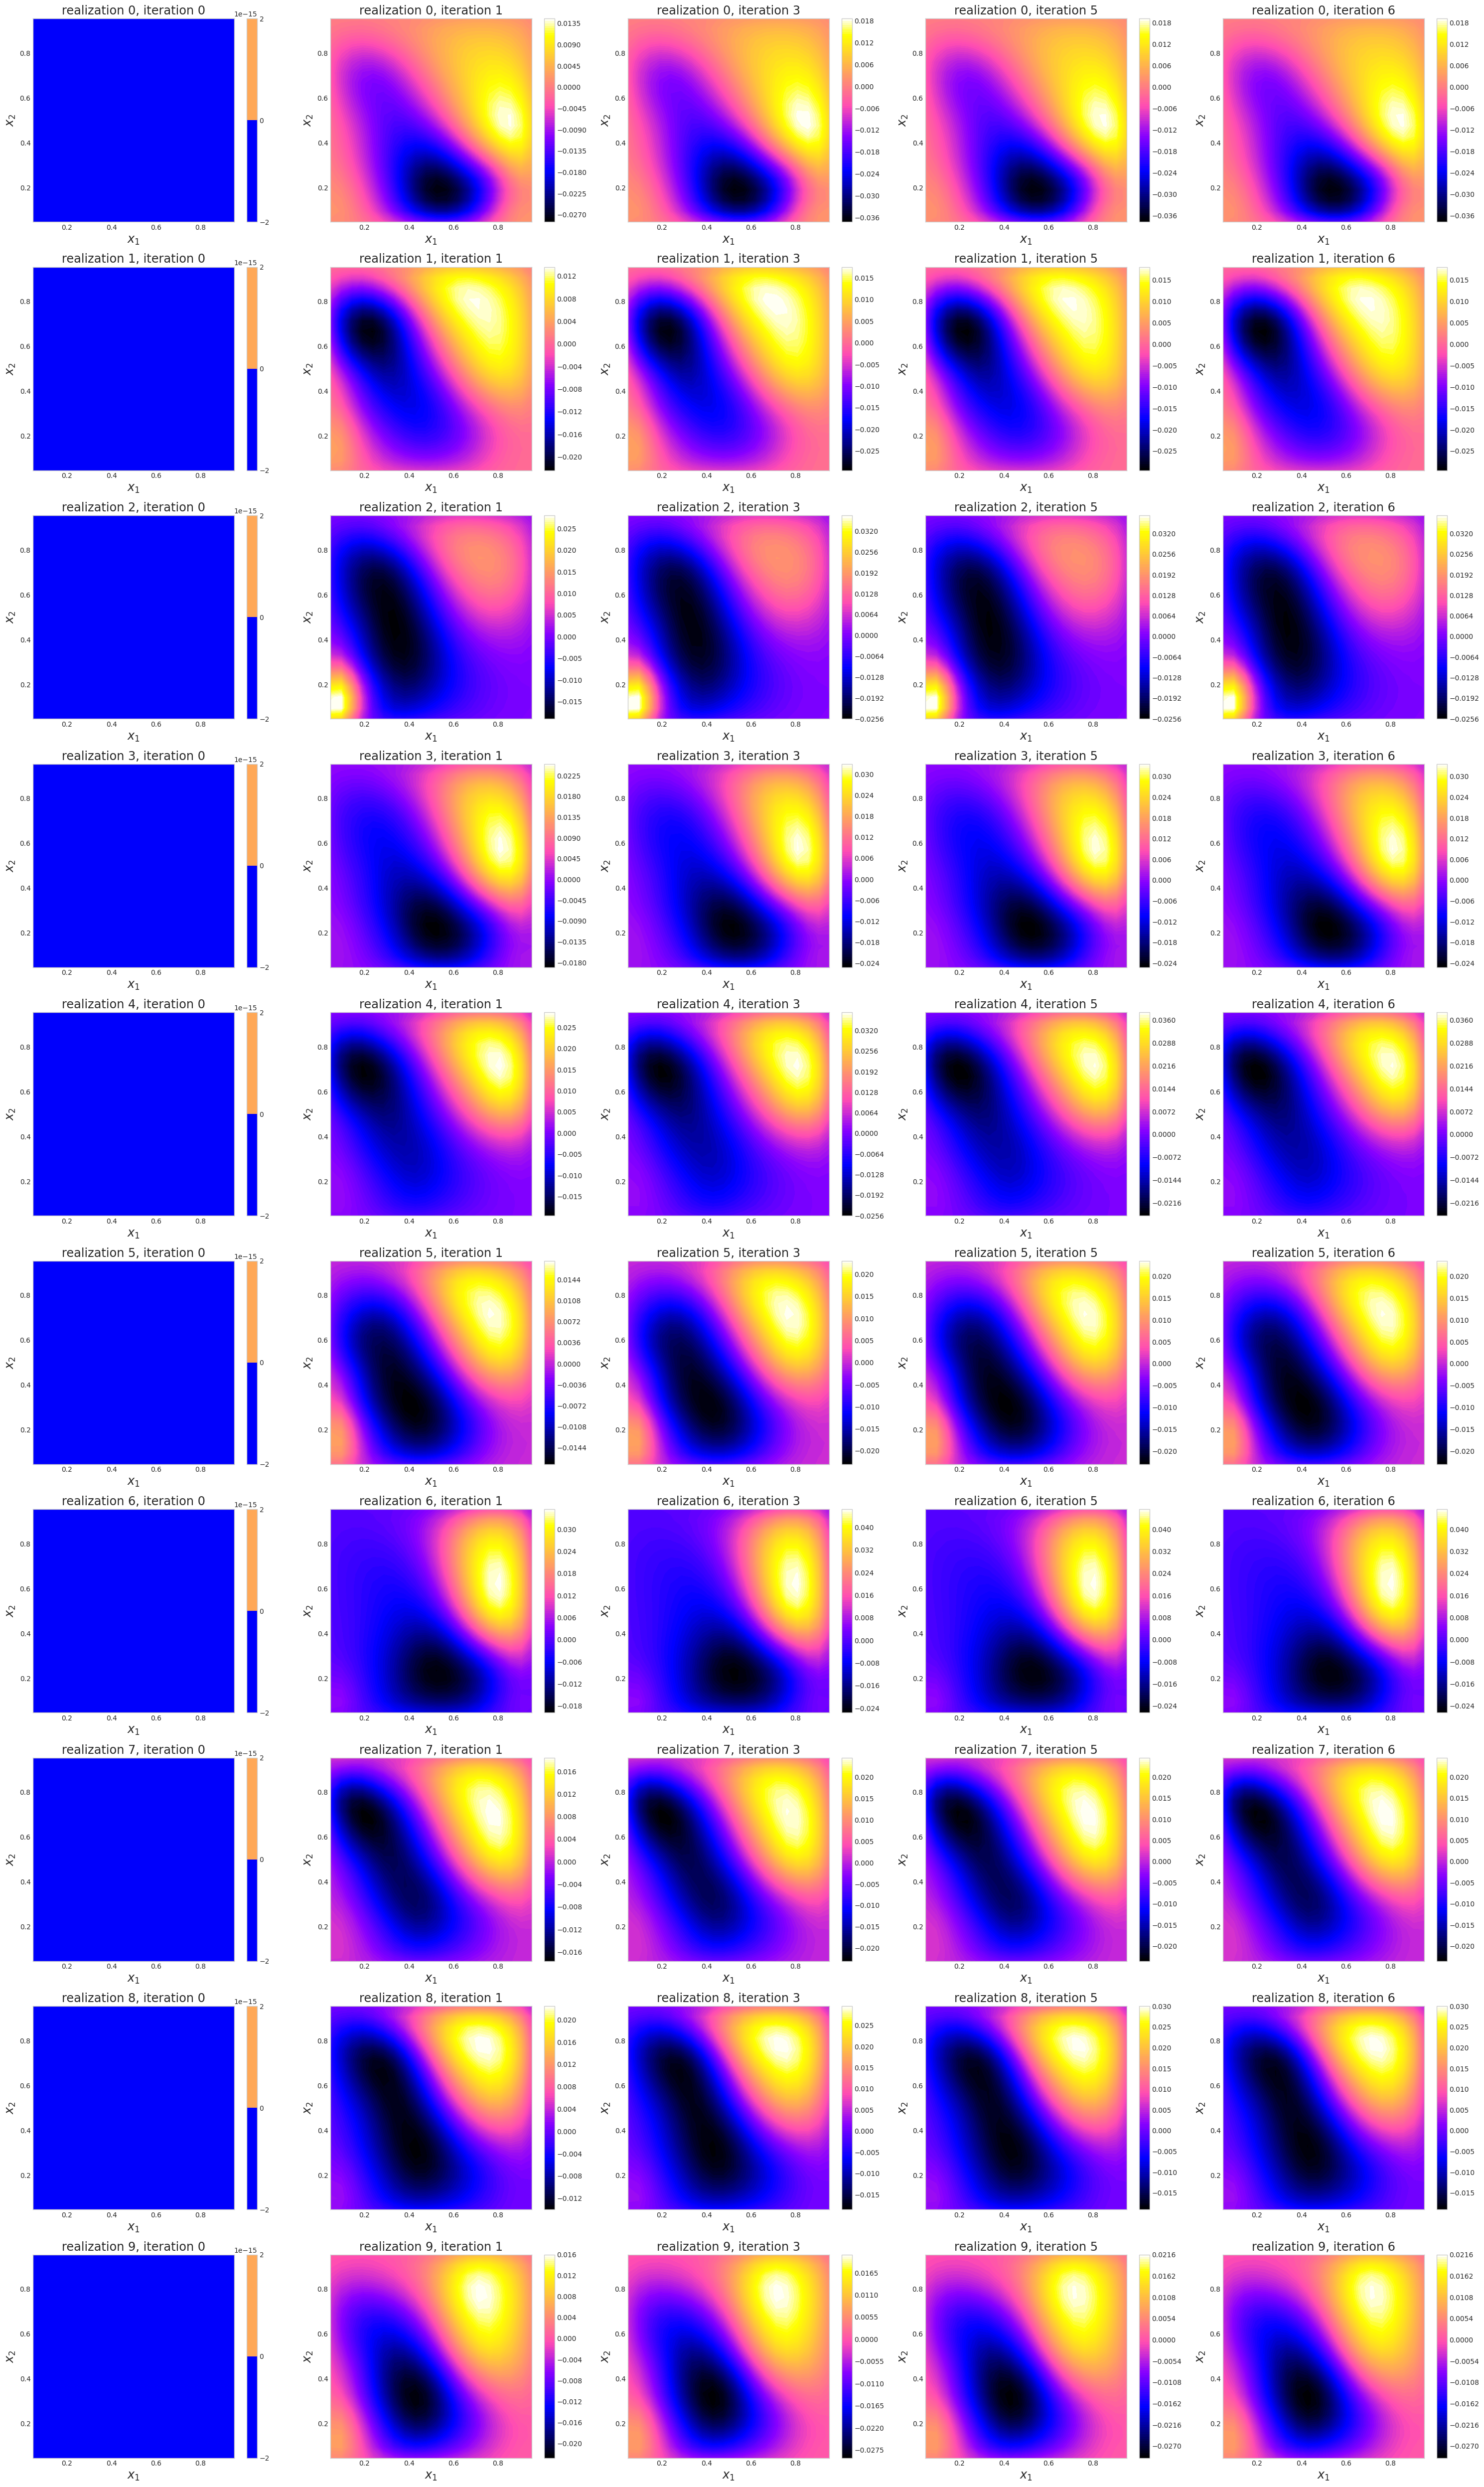

In [14]:
iterticks = [0,vs.size(1)//4,vs.size(1)//2,vs.size(1)*3//4,vs.size(1)-1]
fig,ax = chonknoris.plot_contourfs(
    data = [[(x1mesh.cpu(),x2mesh.cpu(),vs[i,j].cpu()) for j in iterticks] for i in range(10)] ,
    cmap = cm.gnuplot2,
    xlabels = r"$x_1$",
    ylabels = r"$x_2$",
    titles = [["realization %d, iteration %d"%(i,j) for j in iterticks] for i in range(10)])

/data2/agsorok/CHONKNORIS/chonknoris/plots.py:159: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,j].legend(frameon=False,fontsize="xx-large")


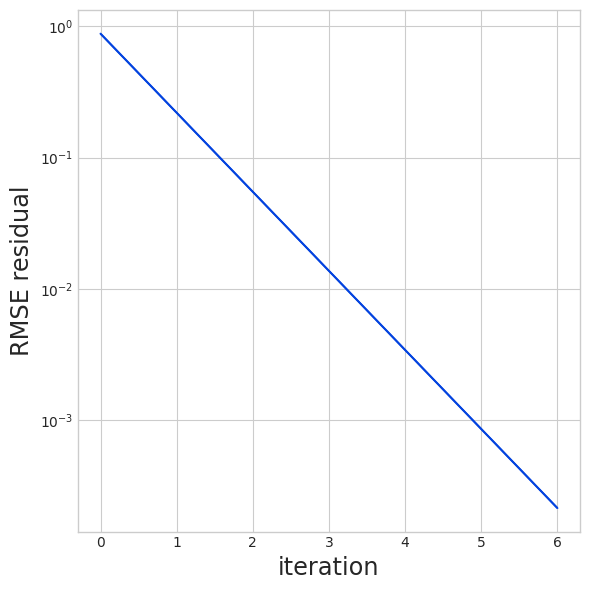

In [15]:
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [(None,data["rmse_resid"],None)],
            #[(None,data["l2rerrors"][:,:-1],None)],

        ]
    ],
    sharex = False,
    ylabels = [["RMSE residual"]],#,r"$L_2$ relative error"]],
    xlabels = "iteration",
    marker=None,
    xlogscale = False,
    colors = [COLORS[0]],
    ylogscale = True)

## Operator Learning Initial Guess

     iter of 1.0e+02 | best loss  | loss      
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 2.21e+02   | 2.21e+02  
            2.50e+01 | 9.35e-03   | 9.35e-03  
            5.00e+01 | 8.03e-03   | 2.78e-01  
            7.50e+01 | 8.03e-03   | 1.77e-02  
            1.00e+02 | 8.03e-03   | 8.86e-03  


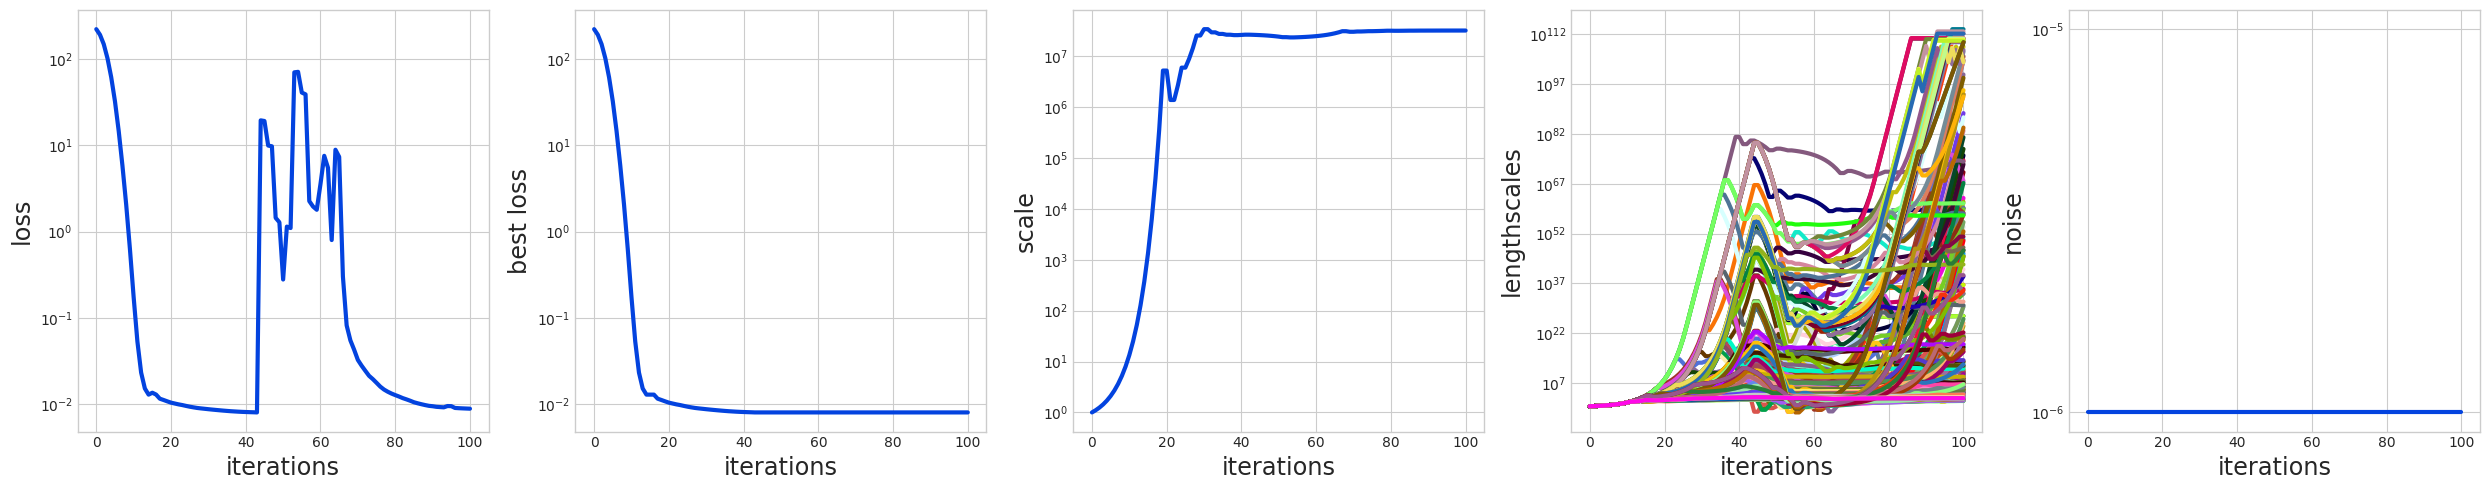

In [16]:
load_params = False 
save_params = True
iterations = 100
d_in = N
d_out = N
fgp_ig = fastgps.StandardGP(
    qp.KernelMatern52(
        d_in,
        scale = 1, 
        shape_scale = [1],
        lengthscales = 1, 
        shape_lengthscales = [d_in],
        torchify = True, 
        device = DEVICE,
        compile_call = False),
    {"x":u_t[:,0,:,:].flatten(start_dim=1).to(DEVICE),"y":vs_t[:,-1,:,:].flatten(start_dim=1).T.to(DEVICE)},
    noise = 1e-6, 
    shape_noise = [1],
    requires_grad_noise = False, 
)
if load_params: 
    fgp_ig.load_params("./out/fgp_ig_params.pt")
fit_data_fgp_ig = fgp_ig.fit(
    loss_metric = "CV",
    cv_weights = 1/torch.linalg.norm(vs_t[:,-1,:,:].flatten(start_dim=1),dim=-1).to(DEVICE),
    iterations = iterations, 
    stop_crit_wait_iterations = np.inf,
    store_hists = True,
    verbose = 25
)
fastgps.plot_fastgps_fit_data(fit_data_fgp_ig,["loss","best_loss","scale","lengthscales","noise"]);
if save_params:
    fgp_ig.save_params("./out/fgp_ig_params.pt")

In [17]:
with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var(), chonknoris.TorchNumThreadsContext(1):
    t0 = torch.cuda.Event(enable_timing=True)
    tend = torch.cuda.Event(enable_timing=True)
    t0.record()
    v0hat_v_fastgp = fgp_ig.post_mean(u_v[:,0,:,:].flatten(start_dim=1).to(DEVICE)).T.reshape((-1,N1,N2))
    tend.record()
    torch.cuda.synchronize()
    time_ig_fastgp = t0.elapsed_time(tend)/1000
print("%s inferance time: %.2e"%("time_ig_fastgp",time_ig_fastgp))

time_ig_fastgp inferance time: 1.22e-02


### Inference

In [18]:
dict_v0s_times = {
    "reference":(v0[vidx],0.),
    # "GPR":(v0hat_v_gp_exact_shared_custom,time_ig_gp_exact_shared_custom),
    # "MLP":(v0hat_v_mlp,time_ig_mlp),
    "Fast GP":(v0hat_v_fastgp,time_ig_fastgp),
}
data_igs = {}
print("models %s: "%str(list(dict_v0s_times.keys())))
for tag,(v0hat_v,tv0) in dict_v0s_times.items():
    print(tag)
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    with chonknoris.TorchNumThreadsContext(1):
        _,data_igs[tag] = pde_solve(f,u_v,v0hat_v,num_newton_iter=100,relaxation=1e-8,lr=.25,vref="last" if tag=="reference" else data_igs["reference"]["vs"][:,-1].to(DEVICE),verbose=10)
    data_igs[tag]["times"] += tv0
print()

models ['reference', 'Fast GP']: 
reference
    iter of 100    | time      | RMSE residual                                                    |
                   |           | 5%           median       mean         95%          finite %     |
    -----------------------------------------------------------------------------------------------
    0              | 1.08e-02  | 8.80e-01     8.80e-01     8.80e-01     8.80e-01     100.0        |
    10             | 8.50e-03  | 4.96e-02     4.96e-02     4.96e-02     4.96e-02     100.0        |
    20             | 8.50e-03  | 2.79e-03     2.79e-03     2.79e-03     2.79e-03     100.0        |
    30             | 8.49e-03  | 1.57e-04     1.57e-04     1.57e-04     1.57e-04     100.0        |
    40             | 8.50e-03  | 8.85e-06     8.85e-06     8.85e-06     8.85e-06     100.0        |
    50             | 8.48e-03  | 4.98e-07     4.98e-07     4.98e-07     4.98e-07     100.0        |
    60             | 8.49e-03  | 2.81e-08     2.81e-08  

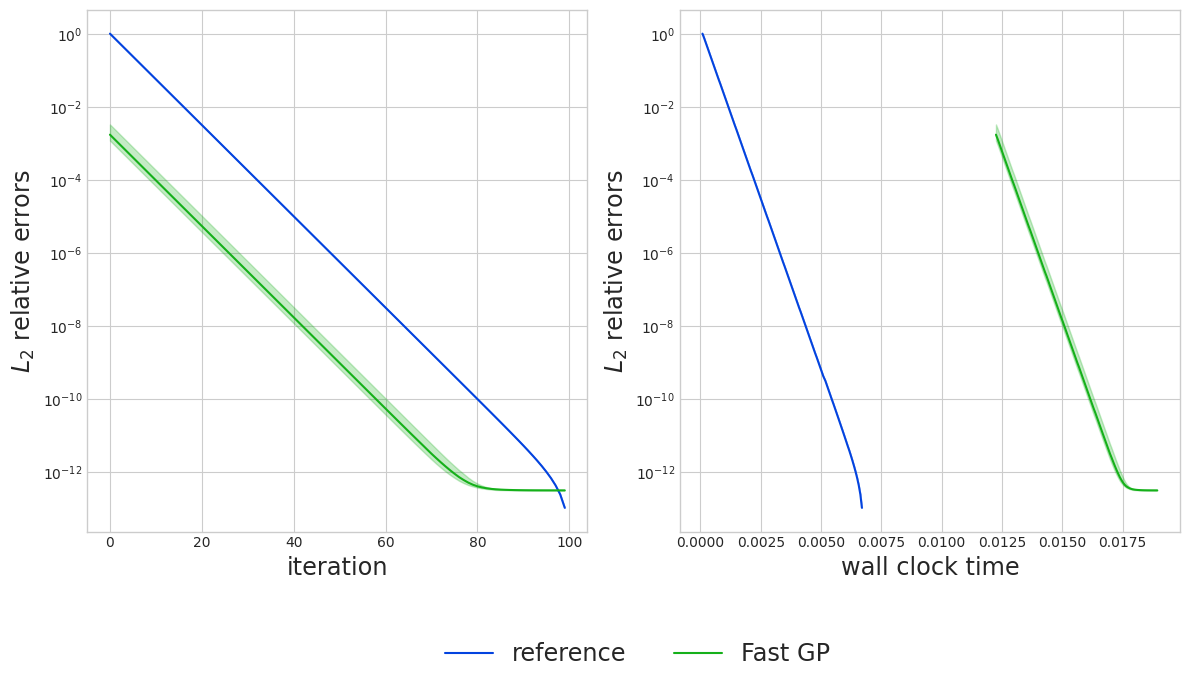

In [19]:
# timing is extremely inconsistent since we are running on GPU
fig,ax = chonknoris.plot_band_strand(
    [
        [
            [(None,data_ig["l2rerrors"][:,:-1],name) for name,data_ig in data_igs.items() if name not in ["GP Indep Vec Exact","GP Indep Vec Exact Shared"]],
            [(data_ig["times"][:-1],data_ig["l2rerrors"][:,:-1],name) for name,data_ig in data_igs.items() if name not in ["GP Indep Vec Exact","GP Indep Vec Exact Shared"]],
        ]
    ],
    ylabels = [2*[r"$L_2$ relative errors"]],
    xlabels = [["iteration","wall clock time"]],
    xlogscale = False,
    ylogscale = True,
    marker = None,
    colors=COLORS,
    qhighs=[.8],
    qlows=[.2],
    plt_band_alphas=[.25],
    sharex=None,
    sharey=False,
)
for i in range(2):
    ax[0,i].get_legend().remove()
ax[0,0].legend(frameon=False,loc="lower center",fontsize="xx-large",ncol=3,bbox_to_anchor=(1.1,-.3));

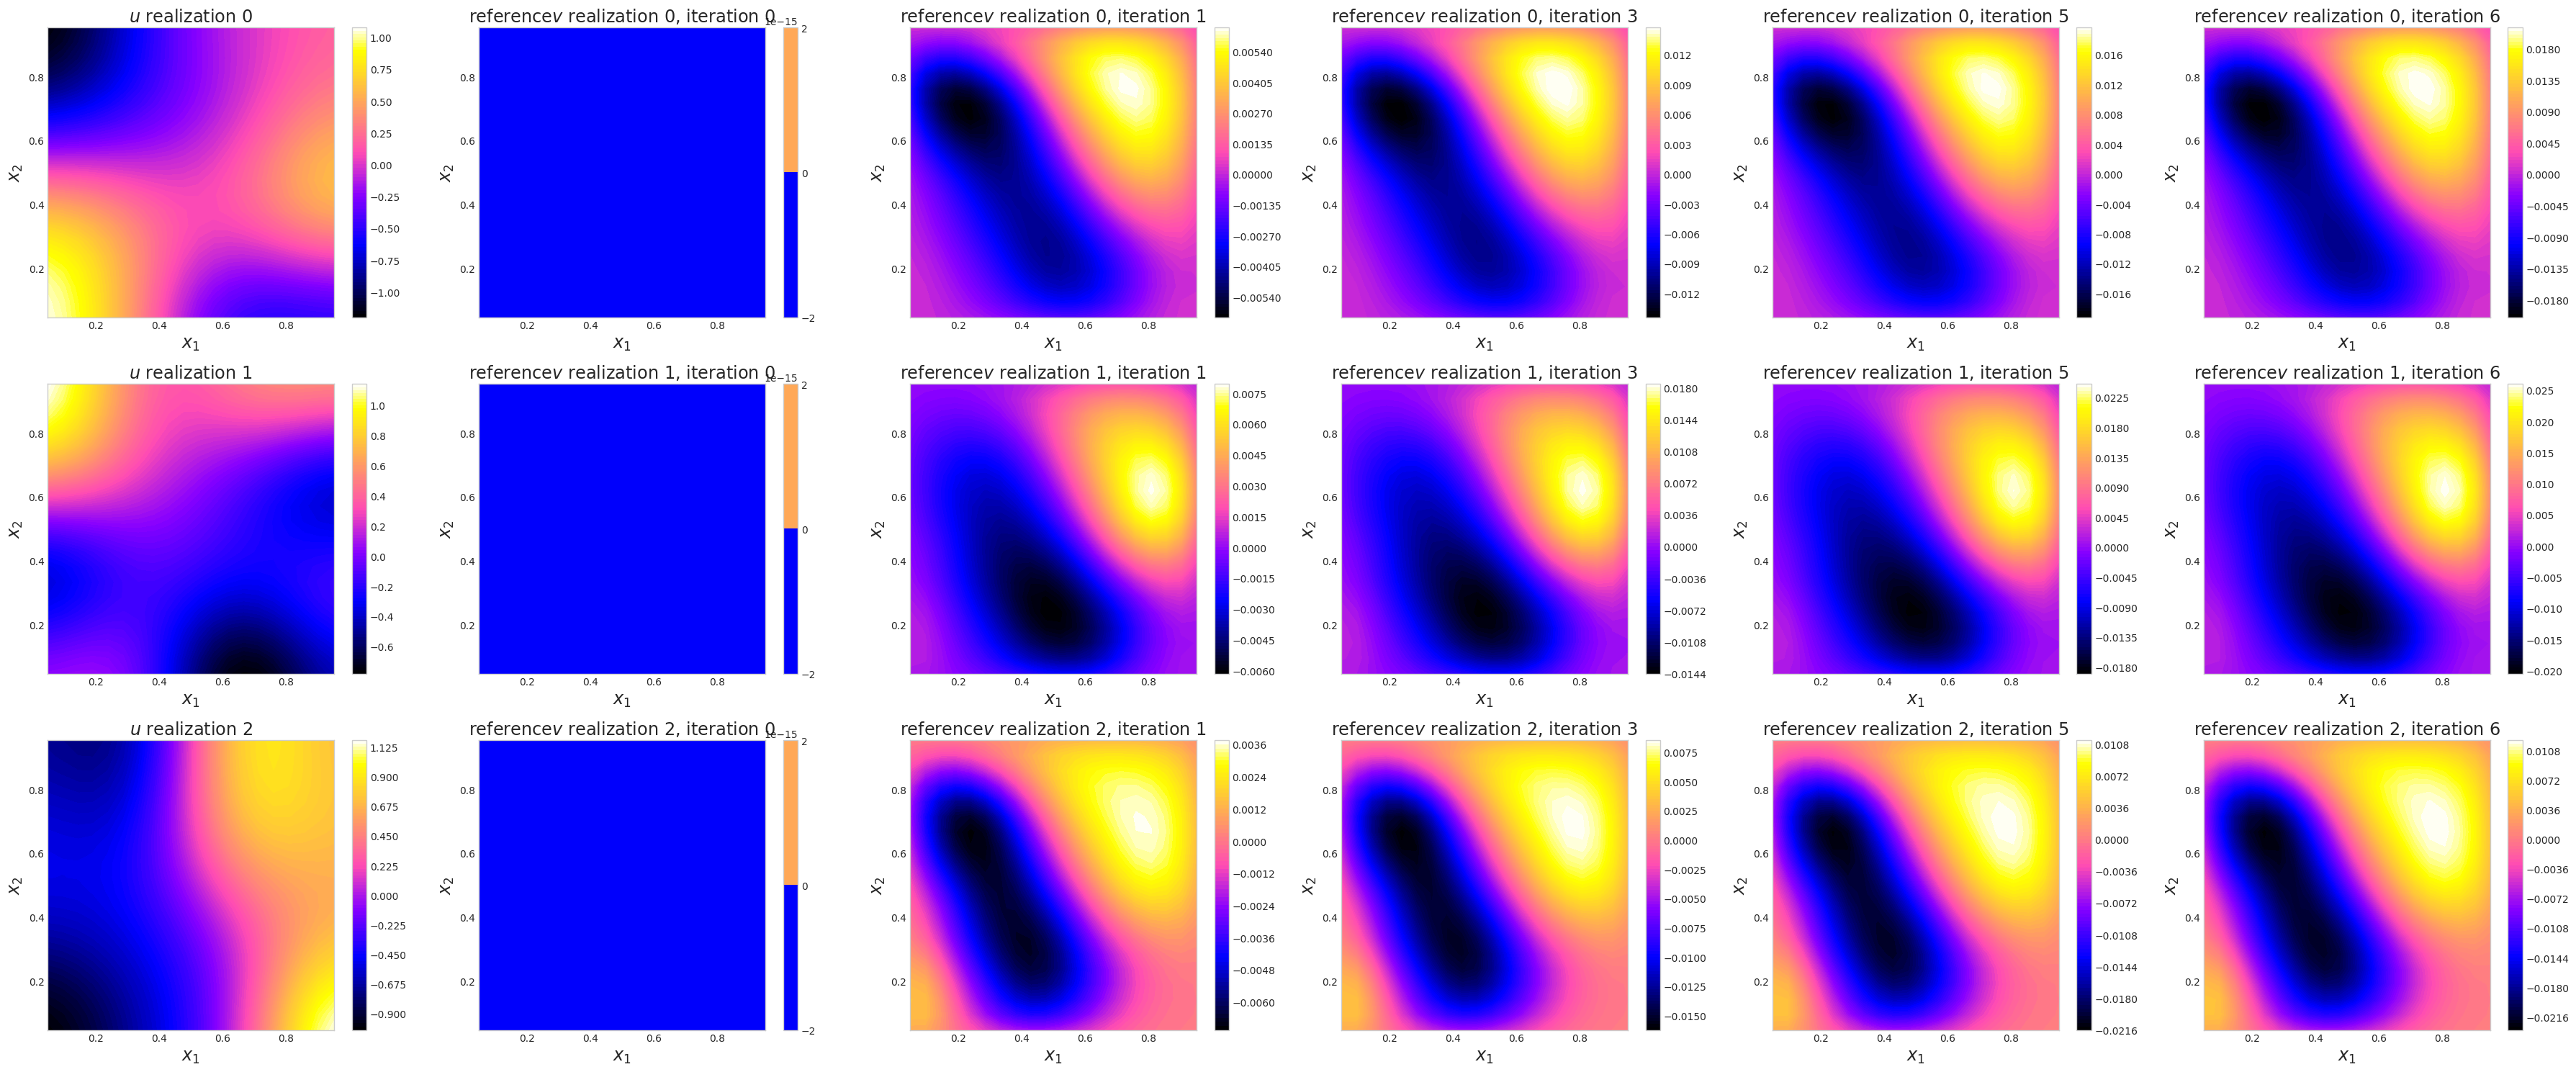

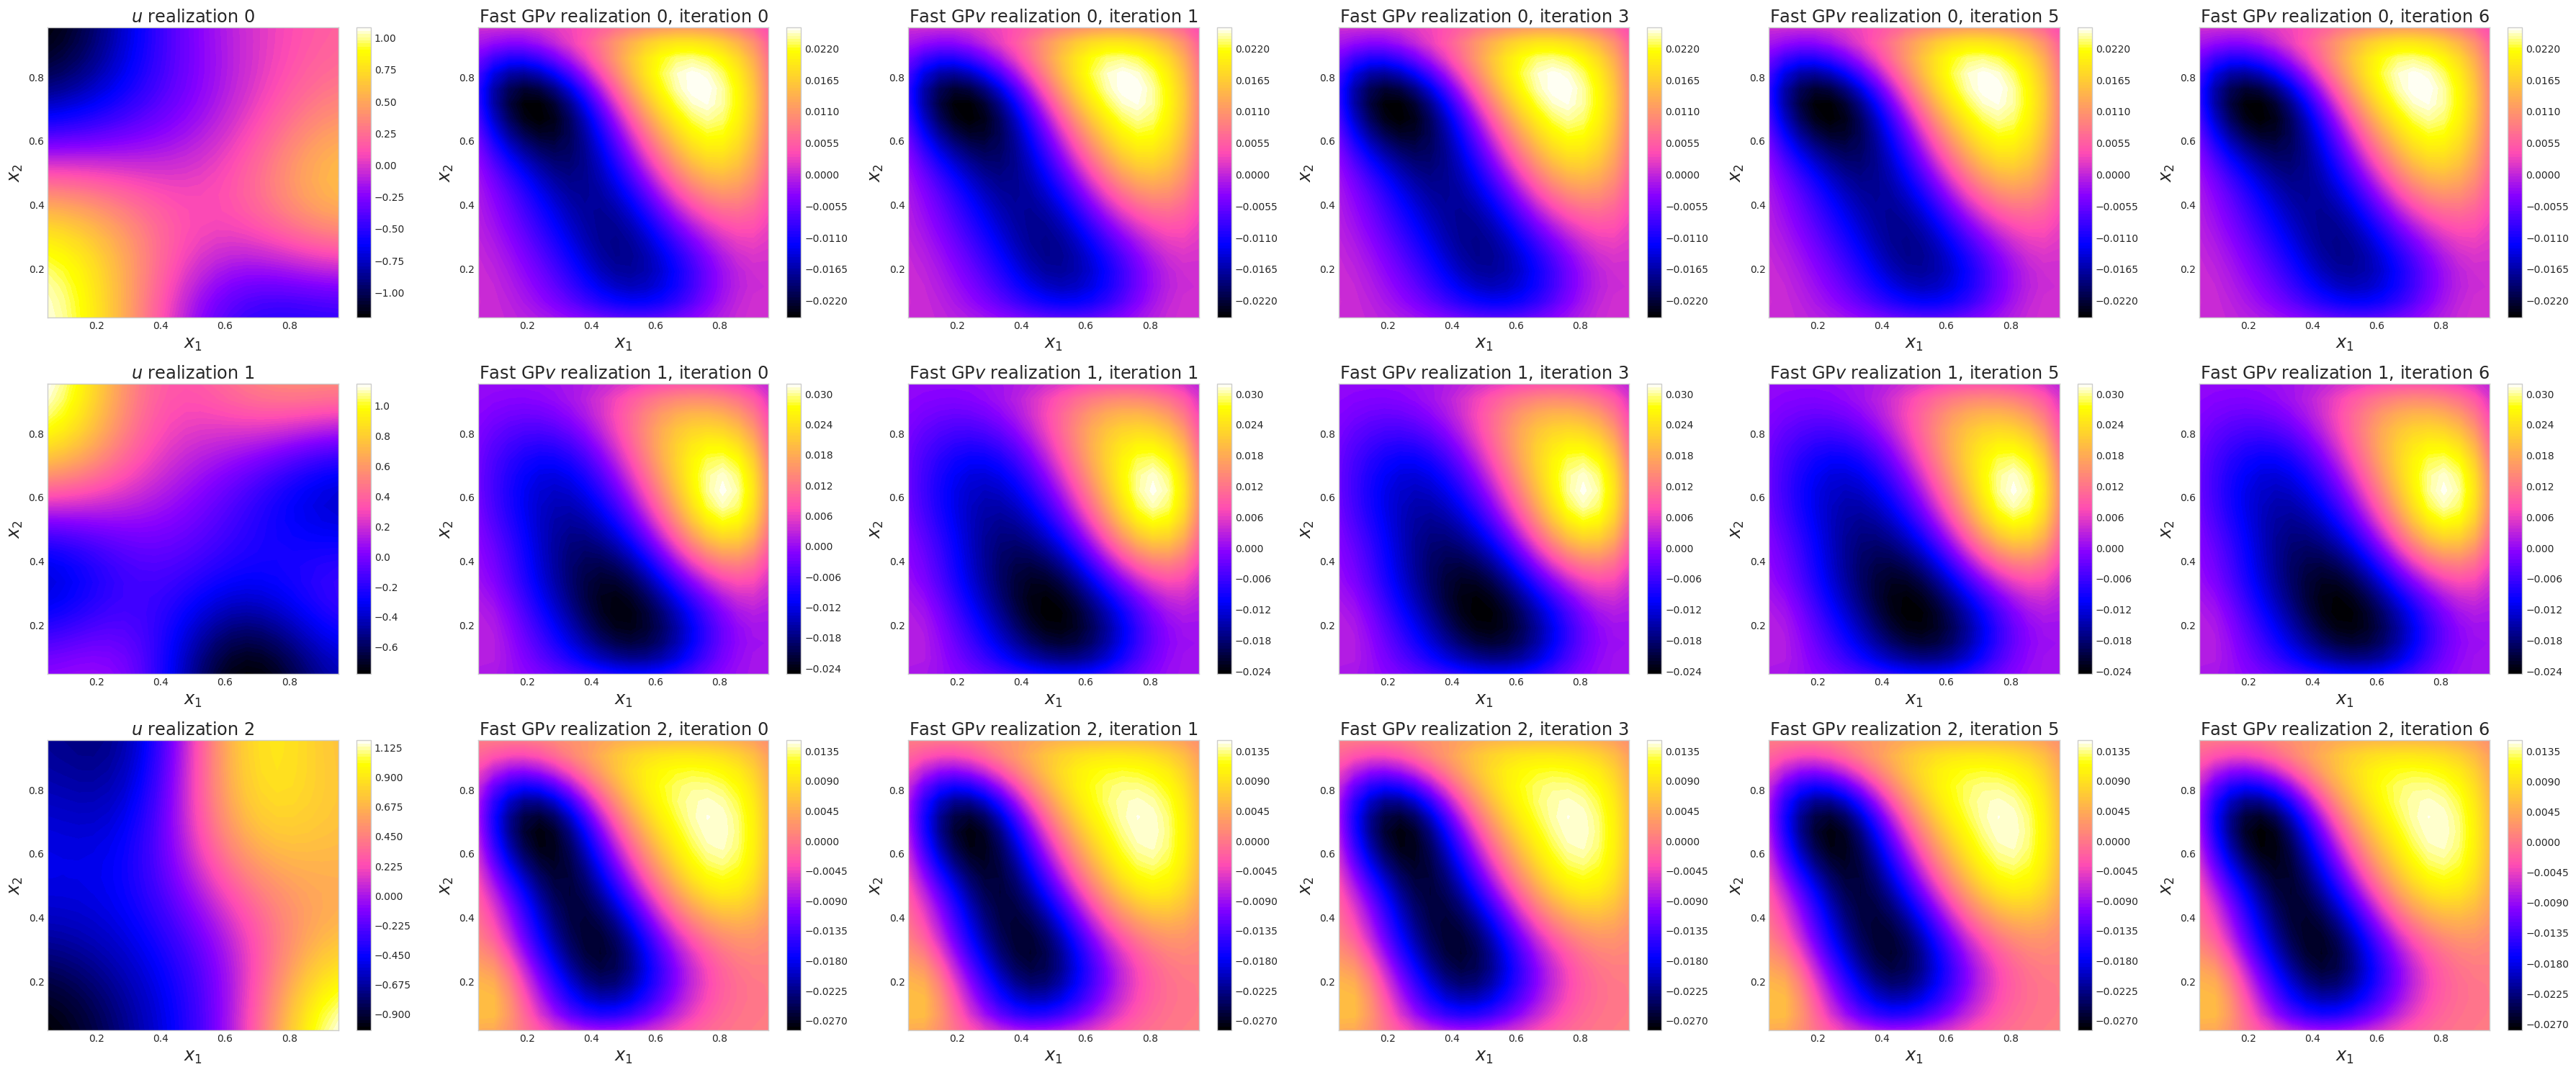

In [20]:
iterticks = [0,vs.size(1)//4,vs.size(1)//2,vs.size(1)*3//4,vs.size(1)-1]
for key in data_igs.keys():
    fig,ax = chonknoris.plot_contourfs(
        data = [[(x1mesh.cpu(),x2mesh.cpu(),u_v[i,0].cpu())]+[(x1mesh.cpu(),x2mesh.cpu(),data_igs[key]["vs"][i,j].cpu()) for j in iterticks] for i in range(3)] ,
        cmap = cm.gnuplot2,
        xlabels = r"$x_1$",
        ylabels = r"$x_2$",
        titles = [[r"$u$ realization %d"%i]+[key+r"$v$ realization %d, iteration %d"%(i,j) for j in iterticks] for i in range(3)])

## Operator Learning Inverse Cholesky Factors

In [21]:
lti0,lti1 = torch.tril_indices(N,N,device=DEVICE)
Lf_t = Linvs_t.to(DEVICE)[:,:,lti0,lti1].flatten(end_dim=-2)
Lf_v = Linvs_v.to(DEVICE)[:,:,lti0,lti1].flatten(end_dim=-2)
Lf_t_mean = Lf_t.mean(0) 
Lf_t_std = Lf_t.std(0)
Lf_t_std[Lf_t_std==0] = 1
Lf_t = (Lf_t-Lf_t_mean)/Lf_t_std
Lf_v = (Lf_v-Lf_t_mean)/Lf_t_std
inputs_t = torch.cat([
    vs_t[:,:-1].to(DEVICE).flatten(start_dim=-2).flatten(end_dim=-2),
    torch.tile(u_t[:,[0],:,:].to(DEVICE),(1,vs_t.size(1)-1,1,1)).flatten(start_dim=-2).flatten(end_dim=-2)],
    dim=1)
inputs_v = torch.cat([
    vs_v[:,:-1].to(DEVICE).flatten(start_dim=-2).flatten(end_dim=-2),
    torch.tile(u_v[:,[0],:,:].to(DEVICE),(1,vs_v.size(1)-1,1,1)).flatten(start_dim=-2).flatten(end_dim=-2)],
    dim=1)
inputs_t_mean = inputs_t.mean(0)
inputs_t_std = inputs_t.std(0)
inputs_t = (inputs_t-inputs_t_mean)/inputs_t_std
inputs_v = (inputs_v-inputs_t_mean)/inputs_t_std
print("inputs_t.shape = %s"%str(tuple(inputs_t.shape)))
print("Lf_t.shape = %s"%str(tuple(Lf_t.shape)))
print("inputs_v.shape = %s"%str(tuple(inputs_v.shape)))
print("Lf_v.shape = %s"%str(tuple(Lf_v.shape)))

inputs_t.shape = (5376, 800)
Lf_t.shape = (5376, 80200)
inputs_v.shape = (768, 800)
Lf_v.shape = (768, 80200)


     iter of 2.5e+01 | best loss  | loss      
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 5.11e+03   | 5.11e+03  
            1.00e+00 | 4.33e+03   | 4.33e+03  
            2.00e+00 | 3.47e+03   | 3.47e+03  
            3.00e+00 | 2.63e+03   | 2.63e+03  
            4.00e+00 | 1.87e+03   | 1.87e+03  
            5.00e+00 | 1.26e+03   | 1.26e+03  
            6.00e+00 | 7.75e+02   | 7.75e+02  
            7.00e+00 | 4.06e+02   | 4.06e+02  
            8.00e+00 | 2.02e+02   | 2.02e+02  
            9.00e+00 | 1.24e+02   | 1.24e+02  
            1.00e+01 | 1.24e+02   | 1.72e+02  
            1.10e+01 | 1.24e+02   | 1.68e+02  
            1.20e+01 | 1.15e+02   | 1.15e+02  
            1.30e+01 | 1.04e+02   | 1.04e+02  
            1.40e+01 | 9.84e+01   | 9.84e+01  
            1.50e+01 | 8.97e+01   | 8.97e+01  
            1.60e+01 | 8.12e+01   | 8.12e+01  
            1.70e+01 | 7.14e+01   | 7.14e+01  
            1.80e+01 | 6.26e+01   | 6.26e+01  
            1

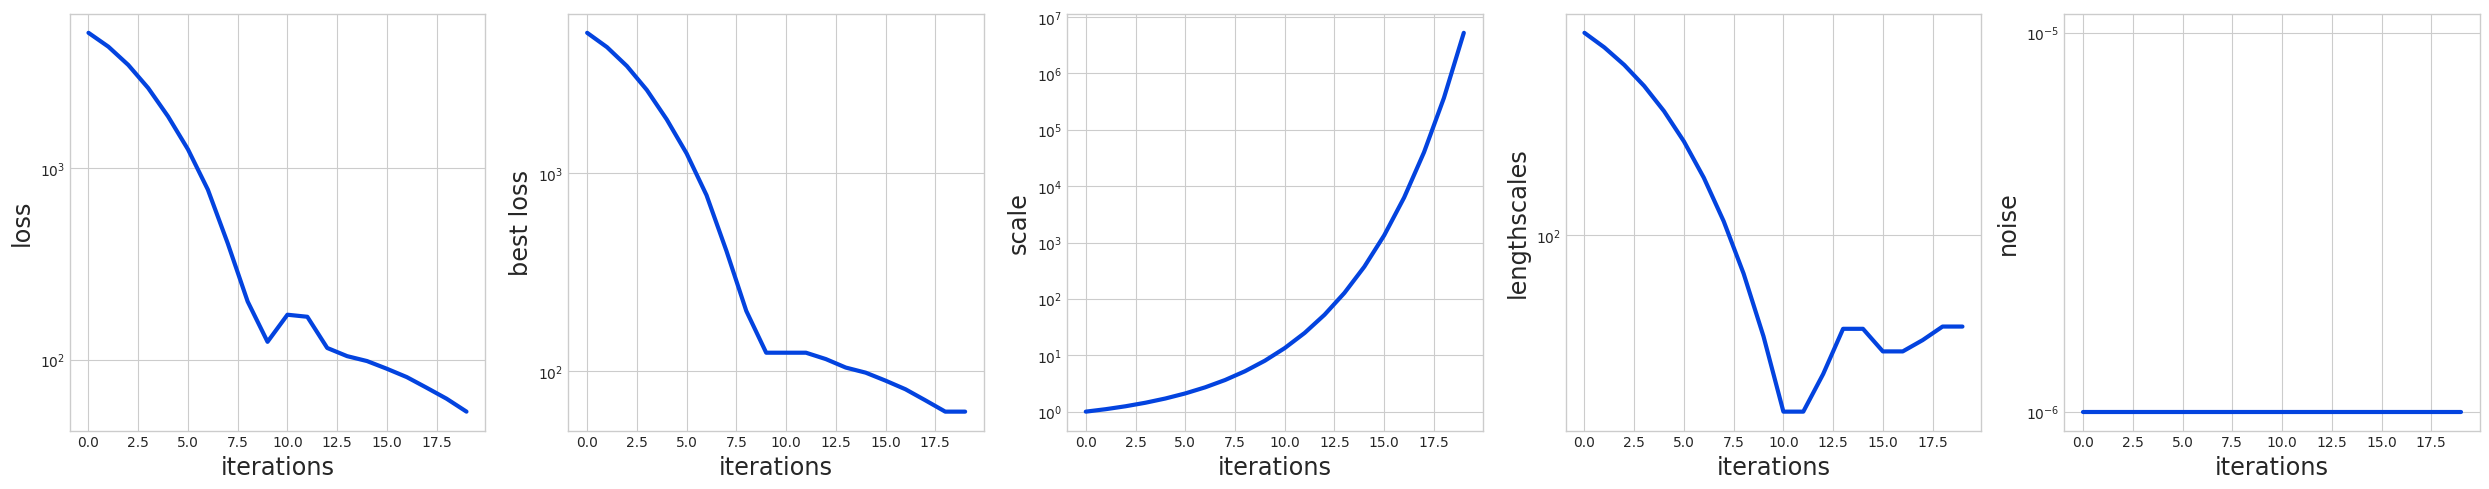

In [23]:
load_params = False 
save_params = True
iterations = 25
d_in = 2*N
d_out = len(lti0)
fgp = fastgps.StandardGP(
    qp.KernelSquaredExponential(
        d_in,
        scale = 1, 
        shape_scale = [1],
        lengthscales=N, 
        shape_lengthscales = [1],
        torchify = True,
        device = DEVICE,
        compile_call = True),
    {"x":inputs_t.to(DEVICE),"y":Lf_t.T.to(DEVICE)},
    noise = 1e-6, 
    shape_noise = [1],
    requires_grad_noise = False, 
)
if load_params: 
    fgp.load_params("./out/fgp_params.pt")
fit_data_fgp = fgp.fit(
    loss_metric = "CV",
    cv_weights = 1/torch.linalg.norm(Lf_t,dim=-1).to(DEVICE),
    iterations = iterations,
    stop_crit_wait_iterations = np.inf,
    store_hists = True,
    #lr = 1e-3,
    verbose = 1,
)
fastgps.plot_fastgps_fit_data(fit_data_fgp,["loss","best_loss","scale","lengthscales","noise"],dict_log_scale=None);
if save_params:
    fgp.save_params("./out/fgp_params.pt")

### Inference

In [24]:
store_Linvs = False # will slow down runtime
num_newton_iter = 5000
line_search = False
line_search_c1 = 1e-8#1e-4 
line_search_beta = .3
line_search_min_lr = 1e-8
#lrs = torch.tensor([1e-2,1.5e-2,2e-2,2.5e-2,3e-2,3.5e-2,4e-2,4.5e-2,5e-2])
#lrs = torch.tensor([7.5e-2,1.25e-1,1.75e-1,2.25e-1,2.75e-1])
# lrs = torch.tensor([.5])
# lrs = torch.tensor([2.5e-2,5e-2,1e-2,2e-1,4e-1,8e-1])
# lrs = torch.tensor([.5,.6,.7,.8,.9])
lrs = torch.tensor([.1])
verbose = max(1,num_newton_iter//10)
# v0_infer_v = torch.zeros((len(vidx),N1,N2),device=DEVICE)
v0_infer_v = v0hat_v_fastgp
#v0_infer_v = v0hat_v_mlp
# lgp_Linv_exact_shared_custom.to(DEVICE)
fgp_predict = lambda x: fgp.post_mean(x).T
# fgp_predict = torch.compile(lambda x: fgp.post_mean(x).T)
print(fgp_predict(inputs_v[:u_v.size(0)]).shape)
models = {
    # "GPR":lgp_Linv_exact_shared_custom,#.to(DEVICE),
    # "MLP":lnn_Linv_mlp.to(DEVICE),
    "Fast GPR": fgp_predict,
}
data_Linvs = {}
print("reference")
# assert len(relaxations)==1, "not sure how to set relaxation for reference solver if there are multiple relaxations"
with chonknoris.TorchNumThreadsContext(1):
    _,data_Linvs["reference"] = pde_solve(f,u_v,v0_infer_v,num_newton_iter=10,relaxation=1e-8,lr=1,vref="last",verbose=1,store_Linvs=store_Linvs,line_search=False)
print("\nmodels %s\n"%str(list(models.keys())))
for tag,model in models.items():
    print(tag)
    # model.eval()
    #model = model.to(DEVICE)
    # ds_Linv_t._lti0,ds_Linv_t._lti1 = ds_Linv_t._lti0.to(DEVICE),ds_Linv_t._lti1.to(DEVICE)
    def predict_Linvs(vs,us):
        inputs = torch.hstack([vs,us[:,0,:]])
        inputs = (inputs-inputs_t_mean)/inputs_t_std
        Linvhat = torch.zeros((vs.size(0),N,N),device=DEVICE)
        with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var():#, gpytorch.settings.eval_cg_tolerance(1e-3):
            Linvs_f = model(inputs)
        Linvhat[:,lti0,lti1] = Linvs_f*Lf_t_std+Lf_t_mean
        return Linvhat
    for lr in lrs:
        print("  lr = %f"%lr)
        with chonknoris.TorchNumThreadsContext(1):
            _,data_Linvs[tag+"_lr_%f"%lr] = pde_solve(f,u_v,v0_infer_v,
                                                     num_newton_iter=num_newton_iter,
                                                     relaxation=0,
                                                     lr=lr,
                                                     vref=data_Linvs["reference"]["vs"][:,-1,:].to(DEVICE),
                                                     verbose=verbose,
                                                     predict_Linvs=predict_Linvs,
                                                     store_Linvs=store_Linvs,
                                                     line_search=line_search,
                                                     line_search_min_lr=line_search_min_lr,
                                                     line_search_c1=line_search_c1,
                                                     line_search_beta=line_search_beta)
print()

torch.Size([128, 80200])
reference
    iter of 10     | time      | RMSE residual                                                    |
                   |           | 5%           median       mean         95%          finite %     |
    -----------------------------------------------------------------------------------------------
    0              | 7.95e-03  | 1.62e-02     2.10e-02     2.63e-02     4.60e-02     100.0        |
    1              | 9.26e-03  | 2.15e-11     6.46e-11     2.38e-08     5.63e-09     100.0        |
    2              | 9.13e-03  | 1.55e-15     1.71e-15     1.97e-15     1.89e-15     100.0        |
    3              | 9.02e-03  | 1.50e-15     1.68e-15     1.69e-15     1.88e-15     100.0        |
    4              | 8.98e-03  | 1.54e-15     1.70e-15     1.70e-15     1.90e-15     100.0        |
    5              | 8.96e-03  | 1.50e-15     1.68e-15     1.68e-15     1.89e-15     100.0        |
    6              | 8.90e-03  | 1.49e-15     1.70e-15     1.70e-

In [25]:
torch.save(
    {
        "data_Linvs": data_Linvs,
        "x1mesh": x1mesh,
        "x2mesh": x2mesh,
        "v0hat_v_fastgp": v0hat_v_fastgp,
        "f": f,
        "u_v": u_v,
    },
    ROOT+"/out/data_final_plot.darcy_2d.pt"
)

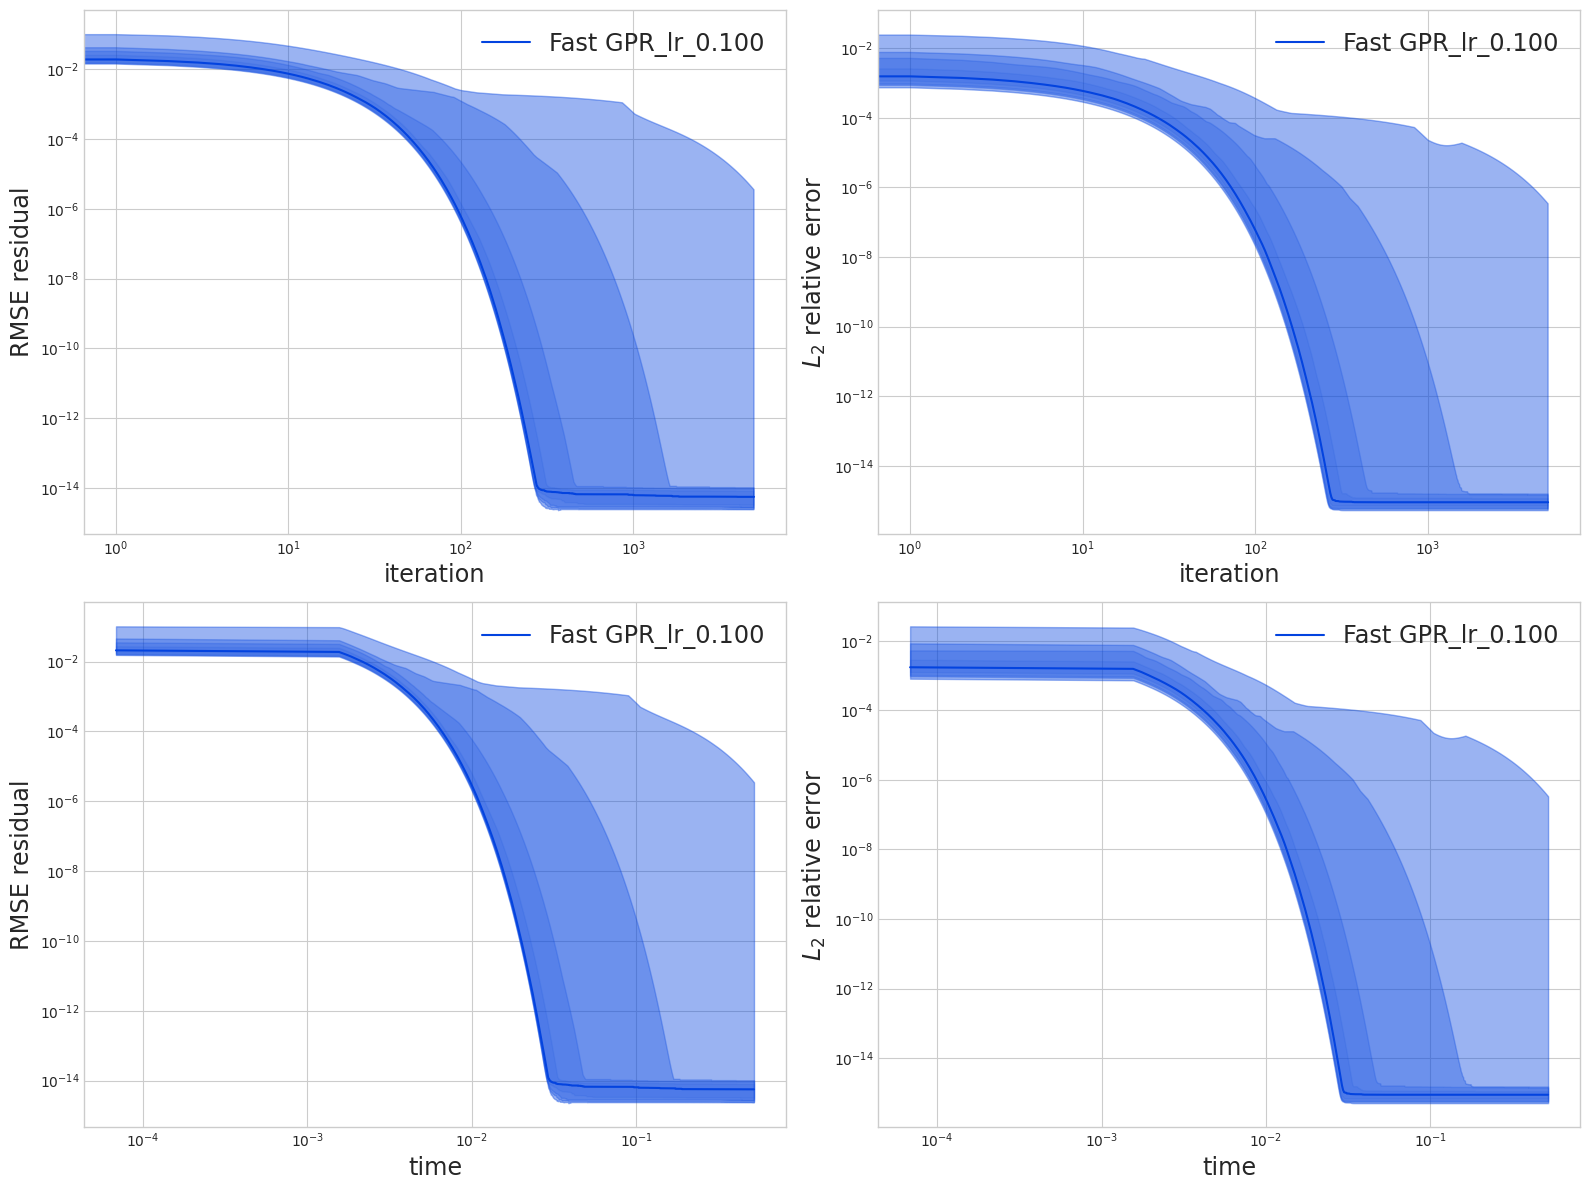

In [26]:
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [(None,data_Linv["rmse_resid"],name.replace("000","")) for name,data_Linv in data_Linvs.items() if name not in ["reference"]],
            [(None,data_Linv["l2rerrors"],name.replace("000","")) for name,data_Linv in data_Linvs.items() if name not in ["reference"]],

        ],
        [
            [(data_Linv["times"],data_Linv["rmse_resid"],name.replace("MLPlr_","").replace("000","")) for name,data_Linv in data_Linvs.items() if name not in ["reference"]],
            [(data_Linv["times"],data_Linv["l2rerrors"],name.replace("MLPlr_","").replace("000","")) for name,data_Linv in data_Linvs.items() if name not in ["reference"]],

        ],
    ],
    #xlabels = "iteration",
    #ylabels = r"$L_2$ relative error",
    xlabels = [["iteration"],["time"]],
    ylabels = [["RMSE residual",r"$L_2$ relative error"]],
    xlogscale = True,
    ylogscale = True,
    marker = None,
    colors=COLORS,
    qhighs=[.75,.9,.95,.99],
    qlows=[.25,.1,.05,.01],
    # plt_band_alphas=[.5,.25,.1,]
    plot_mean=False,
    fsx=6,
    fsy=8,
    use_nan_funcs=True)
# fig.savefig("figs/convergence.pdf")

/tmp/ipykernel_747750/437880922.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels([r"$10^{%s}$"%(int(_t) if _t%1==0 else _t) for _t in ax[0].get_yticks()])


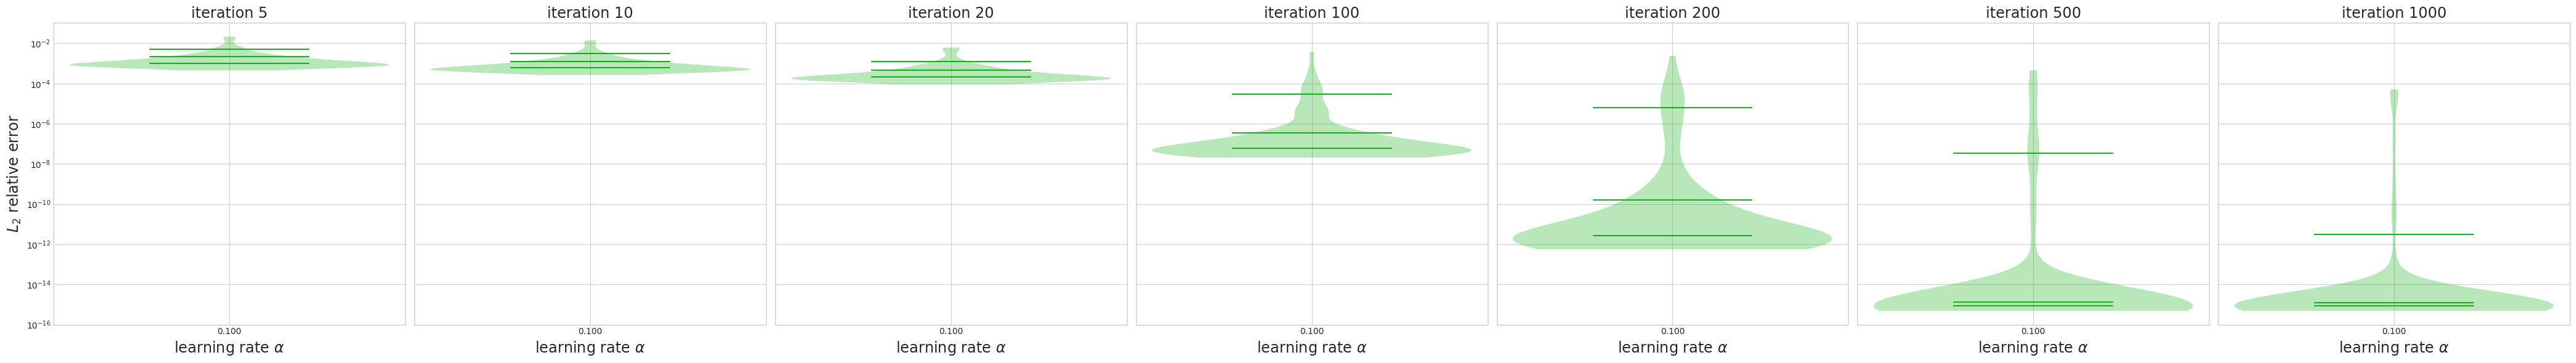

In [27]:
# iterticks = [10,20,30,40]
iterticks = [5,10,20,100,200,500,1000]
ncols = len(iterticks)
fig,ax = pyplot.subplots(nrows=1,ncols=ncols,figsize=(6*ncols,6),sharex=True,sharey=True)
ax = np.atleast_1d(ax)
violins = []
for i,itick in enumerate(iterticks):
    for j,(name,data_Linv) in enumerate(data_Linvs.items()):
        if name == "reference": continue
        color = COLORS[j]
        pltdata = torch.log10(data_Linv["l2rerrors"][:,itick]).clone()
        pltdata = pltdata[~pltdata.isnan()]
        pltdata = pltdata[~pltdata.isnan()]
        violin = ax[i].violinplot(pltdata,[j],showmeans=False,showextrema=False,quantiles=[.5,.82,.95])
        if i==0: violins += [violin]
        for v in violin["bodies"]: v.set_facecolor(color)
        #violin["cmeans"].set_colors("k")
        violin["cquantiles"].set_colors(color)
    ax[i].set_title("iteration %d"%itick,fontsize="xx-large")
    ax[i].set_xlabel(r"learning rate $\alpha$",fontsize="xx-large")
ax[0].set_ylabel(r"$L_2$ relative error",fontsize="xx-large")
ax[0].set_yticklabels([r"$10^{%s}$"%(int(_t) if _t%1==0 else _t) for _t in ax[0].get_yticks()])
ax[0].set_xticks([j for j in range(1,len(lrs)+1)])
ax[0].set_xticklabels([r"%.3f"%lrs[j] for j in range(len(lrs))]);
#fig.legend(violins,labels=lrs)
#ax[0].legend()
#ax[0].set_yscale("log",base=10)
fig.tight_layout()
# fig.savefig("figs/violins_new.pdf")

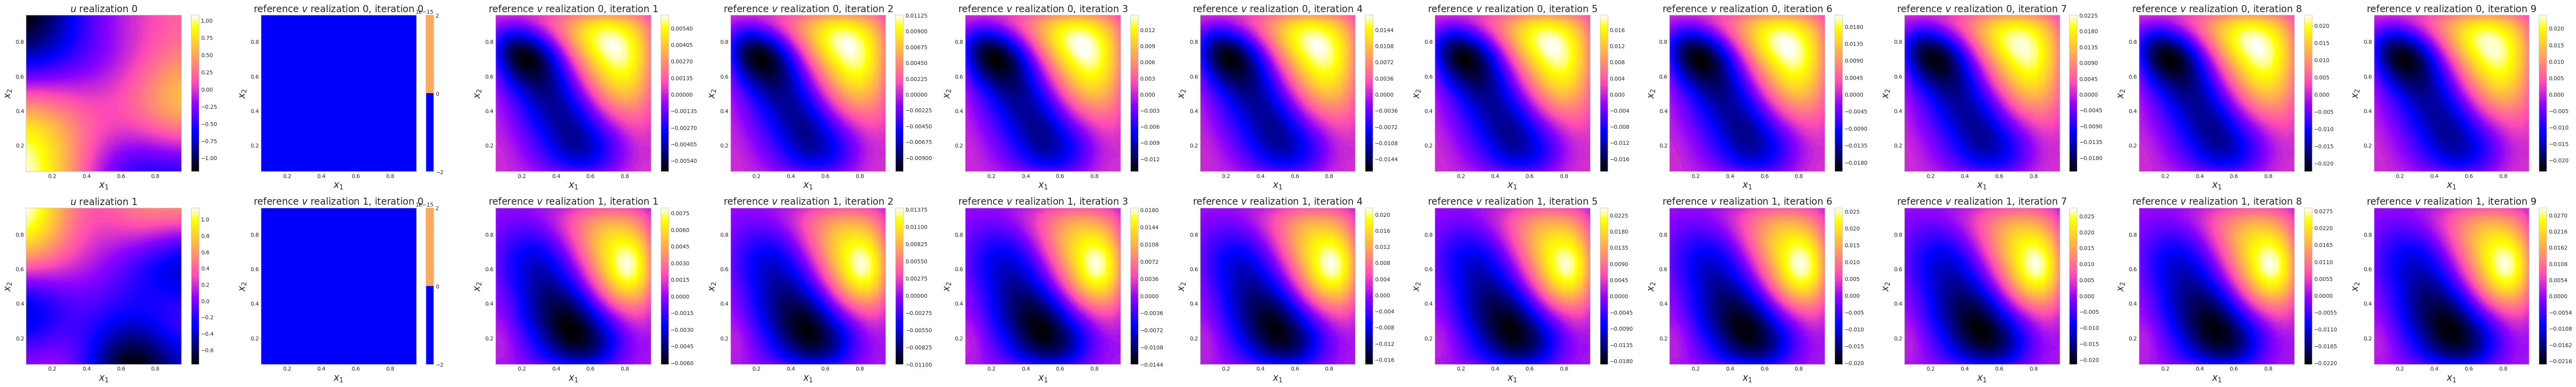

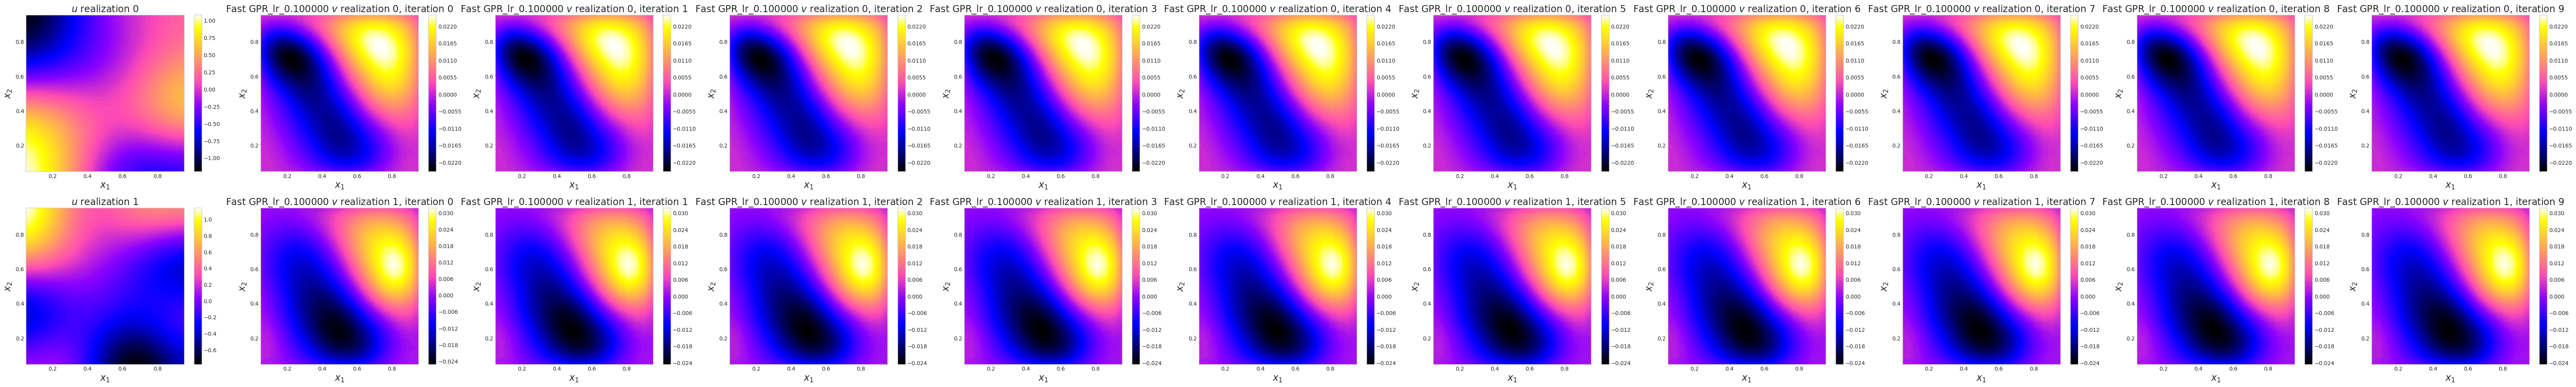

In [28]:
key = list(data_Linvs.keys())[1] 
inf_idxs = torch.where(~torch.isfinite(data_Linvs[key]["rmse_resid"][:,-1]))[0]
iterticks = [i for i in range(0,10,1)]
itoshow = [i for i in range(2)]+inf_idxs[:1].tolist()
fig,ax = chonknoris.plot_contourfs(
    data = [[(x1mesh.cpu(),x2mesh.cpu(),u_v[i,0].cpu())]+[(x1mesh.cpu(),x2mesh.cpu(),data_igs["reference"]["vs"][i,j].cpu()) for j in iterticks] for i in itoshow] ,
    cmap = cm.gnuplot2,
    xlabels = r"$x_1$",
    ylabels = r"$x_2$",
    titles = [[r"$u$ realization %d"%i]+["reference $v$ realization %d, iteration %d"%(i,j) for j in iterticks] for i in itoshow])
for key in [key]: # data_Linvs.keys()
    fig,ax = chonknoris.plot_contourfs(
        data = [[(x1mesh.cpu(),x2mesh.cpu(),u_v[i,0].cpu())]+[(x1mesh.cpu(),x2mesh.cpu(),data_Linvs[key]["vs"][i,j].cpu()) for j in iterticks] for i in itoshow] ,
        cmap = cm.gnuplot2,
        xlabels = r"$x_1$",
        ylabels = r"$x_2$",
        titles = [[r"$u$ realization %d"%i]+[key+r" $v$ realization %d, iteration %d"%(i,j) for j in iterticks] for i in itoshow])

## Timing Comparisonm

In [31]:
N_times_comp = 8

In [33]:
with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var(), chonknoris.TorchNumThreadsContext(1):
    times_ig = torch.empty(N_times_comp)
    for i in range(N_times_comp):
        t0 = torch.cuda.Event(enable_timing=True)
        tend = torch.cuda.Event(enable_timing=True)
        t0.record()
        _ = fgp_ig.post_mean(u_v[[[i]],0,:,:].flatten(start_dim=1).to(DEVICE)).T.reshape((-1,N1,N2))
        tend.record()
        torch.cuda.synchronize()
        times_ig[i] = t0.elapsed_time(tend)/1000
    print("times_ig")
    print(times_ig) 
    print("times_ig.median() = %.1e"%times_ig.median())

times_ig
tensor([0.0018, 0.0012, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011])
times_ig.median() = 1.1e-03


In [39]:
with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var(), chonknoris.TorchNumThreadsContext(1):
    times_chonknoris_model = torch.empty(N_times_comp)
    for i in range(N_times_comp):
        t0 = torch.cuda.Event(enable_timing=True)
        tend = torch.cuda.Event(enable_timing=True)
        t0.record()
        fgp.post_mean(torch.rand(1,fgp.d,device=DEVICE))
        tend.record()
        torch.cuda.synchronize()
        times_chonknoris_model[i] = t0.elapsed_time(tend)/1000
    print("times_chonknoris_model")
    print(times_chonknoris_model) 
    print("times_chonknoris_model.median() = %.1e"%times_chonknoris_model.median())

times_chonknoris_model
tensor([0.0036, 0.0032, 0.0031, 0.0031, 0.0030, 0.0030, 0.0030, 0.0030])
times_chonknoris_model.median() = 3.0e-03


In [43]:
with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var(), chonknoris.TorchNumThreadsContext(1):
    times_chonknoris = torch.empty(N_times_comp)
    for i in range(N_times_comp):
        t0 = torch.cuda.Event(enable_timing=True)
        tend = torch.cuda.Event(enable_timing=True)
        t0.record()
        _ = pde_solve(f,u_v[[i]],v0_infer_v[[i]],
                                                     num_newton_iter=num_newton_iter,
                                                     relaxation=0,
                                                     lr=lr,
                                                     vref=data_Linvs["reference"]["vs"][[i],-1,:].to(DEVICE),
                                                     verbose=verbose,
                                                     predict_Linvs=predict_Linvs,
                                                     store_Linvs=store_Linvs,
                                                     line_search=line_search,
                                                     line_search_min_lr=line_search_min_lr,
                                                     line_search_c1=line_search_c1,
                                                     line_search_beta=line_search_beta)
        tend.record()
        torch.cuda.synchronize()
        times_chonknoris[i] = t0.elapsed_time(tend)/1000
    print("times_chonknoris")
    print(times_chonknoris) 
    print("times_chonknoris.median() = %.1e"%times_chonknoris.median())

    iter of 5000   | time      | RMSE residual                                                    | L2 relative error                                   |
                   |           | 5%           median       mean         95%          finite %     | 5%           median       mean         95%          |
    -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0              | 6.74e-03  | 1.93e-02     1.93e-02     1.93e-02     1.93e-02     100.0        | 1.75e-03     1.75e-03     1.75e-03     1.75e-03     |
    500            | 3.49e-03  | 7.65e-15     7.65e-15     7.65e-15     7.65e-15     100.0        | 4.71e-16     4.71e-16     4.71e-16     4.71e-16     |
    1000           | 3.47e-03  | 7.65e-15     7.65e-15     7.65e-15     7.65e-15     100.0        | 4.71e-16     4.71e-16     4.71e-16     4.71e-16     |
    1500           | 3